In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.cm as cm
import pandas as pd

### preprocessing the data.

In [3]:
#parse the foodweb data

file_path = "Foodweb/data.xls"


#read the data
data = pd.read_excel(file_path)
#There are 2 different data sets in the file (ID,TSN,Name,Phylum) then a gap and it repeats again for the second data set (ID,TSN,Name,Phylum)
#separate the data into 2 dataframes
intertidal = data.iloc[:, :4]
#keep data1 until the first nan value row
intertidal = intertidal[intertidal.notna().all(axis=1)]
nearshore = data.iloc[:, 5:]
nearshore

,Sanak Nearshore Marine Food Web,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,ID,TSN,Name,Phylum
1,1,10031,Gymnodinium,Pyrrophycophyta
2,2,10212,Peridinium,Pyrrophycophyta
3,3,10340,Protoperidinium,Pyrrophycophyta
4,4,10359,Gonyaulax,Pyrrophycophyta
...,...,...,...,...
509,509,179725,Corvus corax,Chordata
510,510,554029,Aethia psittacula,Chordata
511,511,554127,Anthus rubescens,Chordata
512,512,686683,Bubo scandiacus,Chordata


In [4]:
#check the Trophic Links sheet
trophic_links = pd.read_excel(file_path, sheet_name="Trophic Links")
trophic_links


,Sanak Intertidal Food Web,Unnamed: 1,Unnamed: 2,Sanak Nearshore Marine Food Web,Unnamed: 4
0,Consumer,Resource,NaN,Consumer,Resource
1,9,9,NaN,1,200
2,9,64,NaN,1,241
3,9,87,NaN,1,244
4,9,150,NaN,2,1
...,...,...,...,...,...
6770,NaN,NaN,NaN,512,504
6771,NaN,NaN,NaN,512,506
6772,NaN,NaN,NaN,512,507
6773,NaN,NaN,NaN,512,508


In [5]:
#separate the data into 2 dataframes (ID,ID) gap (ID,ID)
intertidal_links = trophic_links.iloc[:, :2]
#also remove the rows with nan value
intertidal_links = intertidal_links[intertidal_links.notna().all(axis=1)]
nearshore_links = trophic_links.iloc[:, 3:5]  # Fix: Only take 2 columns, not all remaining
#also remove the rows with nan value for nearshore links
nearshore_links = nearshore_links[nearshore_links.notna().all(axis=1)]

#print the dataframes
intertidal_links

,Sanak Intertidal Food Web,Unnamed: 1
0,Consumer,Resource
1,9,9
2,9,64
3,9,87
4,9,150
...,...,...
1800,234,226
1801,234,228
1802,234,229
1803,234,230


In [6]:
nearshore_links

,Sanak Nearshore Marine Food Web,Unnamed: 4
0,Consumer,Resource
1,1,200
2,1,241
3,1,244
4,2,1
...,...,...
6770,512,504
6771,512,506
6772,512,507
6773,512,508


In [7]:
intertidal.columns = intertidal.iloc[0]
intertidal = intertidal.iloc[1:]
intertidal.head()

,ID,TSN,Name,Phylum
1,1,10824,Pilayella littoralis,Phaeophyta
2,2,11217,Laminaria,Phaeophyta
3,3,11246,Agarum,Phaeophyta
4,4,11250,Costaria costata,Phaeophyta
5,5,11255,Saccharina sessile,Phaeophyta


In [8]:
#same for nearshore
nearshore.columns=nearshore.iloc[0]
nearshore=nearshore.iloc[1:]
nearshore.head()

,ID,TSN,Name,Phylum
1,1,10031,Gymnodinium,Pyrrophycophyta
2,2,10212,Peridinium,Pyrrophycophyta
3,3,10340,Protoperidinium,Pyrrophycophyta
4,4,10359,Gonyaulax,Pyrrophycophyta
5,5,10397,Ceratium,Pyrrophycophyta


In [9]:
#same for intertidal links
intertidal_links.columns = intertidal_links.iloc[0]
intertidal_links = intertidal_links.iloc[1:]
intertidal_links.head()

,Consumer,Resource
1,9,9
2,9,64
3,9,87
4,9,150
5,9,168


In [10]:
nearshore_links.columns = nearshore_links.iloc[0]
nearshore_links = nearshore_links.iloc[1:]
nearshore_links.head()


,Consumer,Resource
1,1,200
2,1,241
3,1,244
4,2,1
5,2,2


#### extracting of data is done here !

### Start merging the tables.

In [11]:
#now we have the dataframe of the nodes and the links
#first lets check if all the nodes of the smallest network are present in the other network
#lets check the intertidal network
#get the TSNS of the intertidal network(the second column)
intertidal_TSNS = intertidal.iloc[:, 1]
#get the TSNS of the nearshore network(the second column)
nearshore_TSNS = nearshore.iloc[:, 1]
#print the length of the nodes
# CHANGE: made it print the unique values only. It avoids counting duplicates and gives better representaion of the network!
# It does not matter here as there are no duplicates.
print(len(intertidal_TSNS.unique()))
print(len(nearshore_TSNS.unique()))



233
513


In [12]:
#since intetidal has less we will check if all the nodes of the intertidal network are present in the nearshore network
#summarize the results
print(intertidal_TSNS.isin(nearshore_TSNS).value_counts())
#almost all of them are present but not all so we cannot disregard it 
#however we can merge the two datasets and add two columns to indicate if the species is intertidal and/or nearshore

#print the intertidals that are not in the nearshore
intertidal_TSNS[~intertidal_TSNS.isin(nearshore_TSNS)]


TSN
True     226
False      7
Name: count, dtype: int64


64      2286
66     43781
69     46211
112    73727
151     9512
153    95500
162     9874
Name: TSN, dtype: object

In [13]:
#first lets merge the two datasets but without the ID column
#select only TSN, Name, and Phylum columns for merging
intertidal_clean = intertidal[["TSN", "Name", "Phylum"]].copy()
nearshore_clean = nearshore[["TSN", "Name", "Phylum"]].copy()

merged_data = pd.merge(intertidal_clean, nearshore_clean, on="TSN", how="outer", suffixes=('_intertidal', '_nearshore'))

#combine Name and Phylum columns - use intertidal values first, then nearshore if intertidal is NaN
merged_data["Name"] = merged_data["Name_intertidal"].fillna(merged_data["Name_nearshore"])
merged_data["Phylum"] = merged_data["Phylum_intertidal"].fillna(merged_data["Phylum_nearshore"])

#drop the separate columns
merged_data = merged_data.drop(["Name_intertidal", "Name_nearshore", "Phylum_intertidal", "Phylum_nearshore"], axis=1)

#add the two columns
merged_data["Intertidal"] = merged_data["TSN"].isin(intertidal_TSNS)
merged_data["Nearshore"] = merged_data["TSN"].isin(nearshore_TSNS)

merged_data

,TSN,Name,Phylum,Intertidal,Nearshore
0,601,Cyanophycota,Cyanophycota,True,True
1,1447,Chrysophyta,Chrysophyta,True,True
2,2135,Prymnesiophyceae,Haptophyta,True,True
3,2286,Bacillariophyta,Bacillariophyta,True,False
4,2546,Coscinodiscus,Bacillariophyta,False,True
...,...,...,...,...,...
515,san419,Phyllobothrium,Platyhelminthes,False,True
516,san420,Nybelinia surmenicola,Platyhelminthes,False,True
517,san455,Thalassomyces,Protozoa,False,True
518,san788,Hysterothylacium aduncum,Nemata,False,True


The number of rows in the `merged_data` must be 520 because there are only 7 entries in intertidal which are not nearshore. Since, there are 513 entries in nearshore, we should get 520.

In [14]:
#now we also need to merge the links but before we do that we need to change the ID's to TSN's
#starting from intertidal dataset we create a dictionary of the ID and TSN
intertidal_ID_TSN = dict(zip(intertidal["ID"], intertidal["TSN"]))
#now we can use this dictionary to map the ID's to TSN's in the intertidal_links dataframe
intertidal_links_TSN = intertidal_links.copy()
intertidal_links_TSN["Consumer"] = intertidal_links_TSN["Consumer"].map(intertidal_ID_TSN)
intertidal_links_TSN["Resource"] = intertidal_links_TSN["Resource"].map(intertidal_ID_TSN)

# Remove rows where mapping failed (NaN values)
intertidal_links_TSN = intertidal_links_TSN.dropna()
print(intertidal_links_TSN)

#now we do the same for the nearshore dataset
nearshore_ID_TSN = dict(zip(nearshore["ID"], nearshore["TSN"]))
#now we can use this dictionary to map the ID's to TSN's in the nearshore_links dataframe
nearshore_links_TSN = nearshore_links.copy()
nearshore_links_TSN["Consumer"] = nearshore_links_TSN["Consumer"].map(nearshore_ID_TSN)
nearshore_links_TSN["Resource"] = nearshore_links_TSN["Resource"].map(nearshore_ID_TSN)

# Remove rows where mapping failed (NaN values)
nearshore_links_TSN = nearshore_links_TSN.dropna()
print(nearshore_links_TSN)

0    Consumer Resource
1      113265   113265
2      113265     2286
3      113265      601
4      113265    93295
6        1447   202421
...       ...      ...
1800   686683   177935
1801   686683   179492
1802   686683   179526
1803   686683   179531
1804    78536    48739

[1689 rows x 2 columns]
0    Consumer Resource
1       10031     2135
2       10031   590745
3       10031      601
4       10212    10031
5       10212    10212
...       ...      ...
6770   686683   177935
6771   686683   179492
6772   686683   179526
6773   686683   179531
6774    78536    48739

[6774 rows x 2 columns]


In [15]:
# We want to create a merged links dataframe with one row per unique (Consumer, Resource) pair,
# and two columns: 'Intertidal' and 'Nearshore', indicating presence (True/False) in each network.

# First, get sets of (Consumer, Resource) tuples for each network
intertidal_links_set = set(tuple(x) for x in intertidal_links_TSN[["Consumer", "Resource"]].values)
nearshore_links_set = set(tuple(x) for x in nearshore_links_TSN[["Consumer", "Resource"]].values)

# Get all unique links
all_links = intertidal_links_set.union(nearshore_links_set)

# Build the merged DataFrame
merged_links = pd.DataFrame(list(all_links), columns=["Consumer", "Resource"])
merged_links["Intertidal"] = merged_links.apply(lambda row: (row["Consumer"], row["Resource"]) in intertidal_links_set, axis=1)
merged_links["Nearshore"] = merged_links.apply(lambda row: (row["Consumer"], row["Resource"]) in nearshore_links_set, axis=1)

merged_links

,Consumer,Resource,Intertidal,Nearshore
0,157215,157215,False,True
1,73293,89609,True,True
2,157152,202421,True,True
3,78979,san14,True,True
4,165427,97106,False,True
...,...,...,...,...
6912,175062,6501,True,True
6913,177013,667083,False,True
6914,164722,82415,False,True
6915,85524,158650,False,True


We successfully merged the links in `merged_links`. Now, we will create a graph with those links and use meta data from `merged_data`.

### creating and visualizing the graph

In [66]:
#now create an nx graph from the merged links dataframe but also use the metadata from the merged_data dataframe
G = nx.DiGraph()

# Add nodes for all unique TSNs in merged_links, with metadata from merged_data if available
all_TSNs = set(merged_links["Consumer"]).union(set(merged_links["Resource"]))

# merged_data should have TSN as a column; if not, adjust accordingly
for tsn in all_TSNs:
    # Try to get metadata for this TSN from merged_data
    if "TSN" in merged_data.columns:
        meta = merged_data[merged_data["TSN"] == tsn]
        if not meta.empty:
            node_attrs = meta.iloc[0].to_dict()
        else:
            node_attrs = {}
    else:
        node_attrs = {}
    G.add_node(tsn, **node_attrs)

# Add edges with attributes for Intertidal and Nearshore presence
for _, row in merged_links.iterrows():
    consumer = row["Consumer"]
    resource = row["Resource"]
    intertidal = row["Intertidal"]
    nearshore = row["Nearshore"]
    G.add_edge(consumer, resource, Intertidal=intertidal, Nearshore=nearshore)




C:\Users\anant\AppData\Local\Temp\ipykernel_2168\3520670299.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  legend_elements = [plt.scatter([], [], c=color, s=100, label=phylum) for phylum, color in phylum_colors.items()]
C:\Users\anant\AppData\Local\Temp\ipykernel_2168\3520670299.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


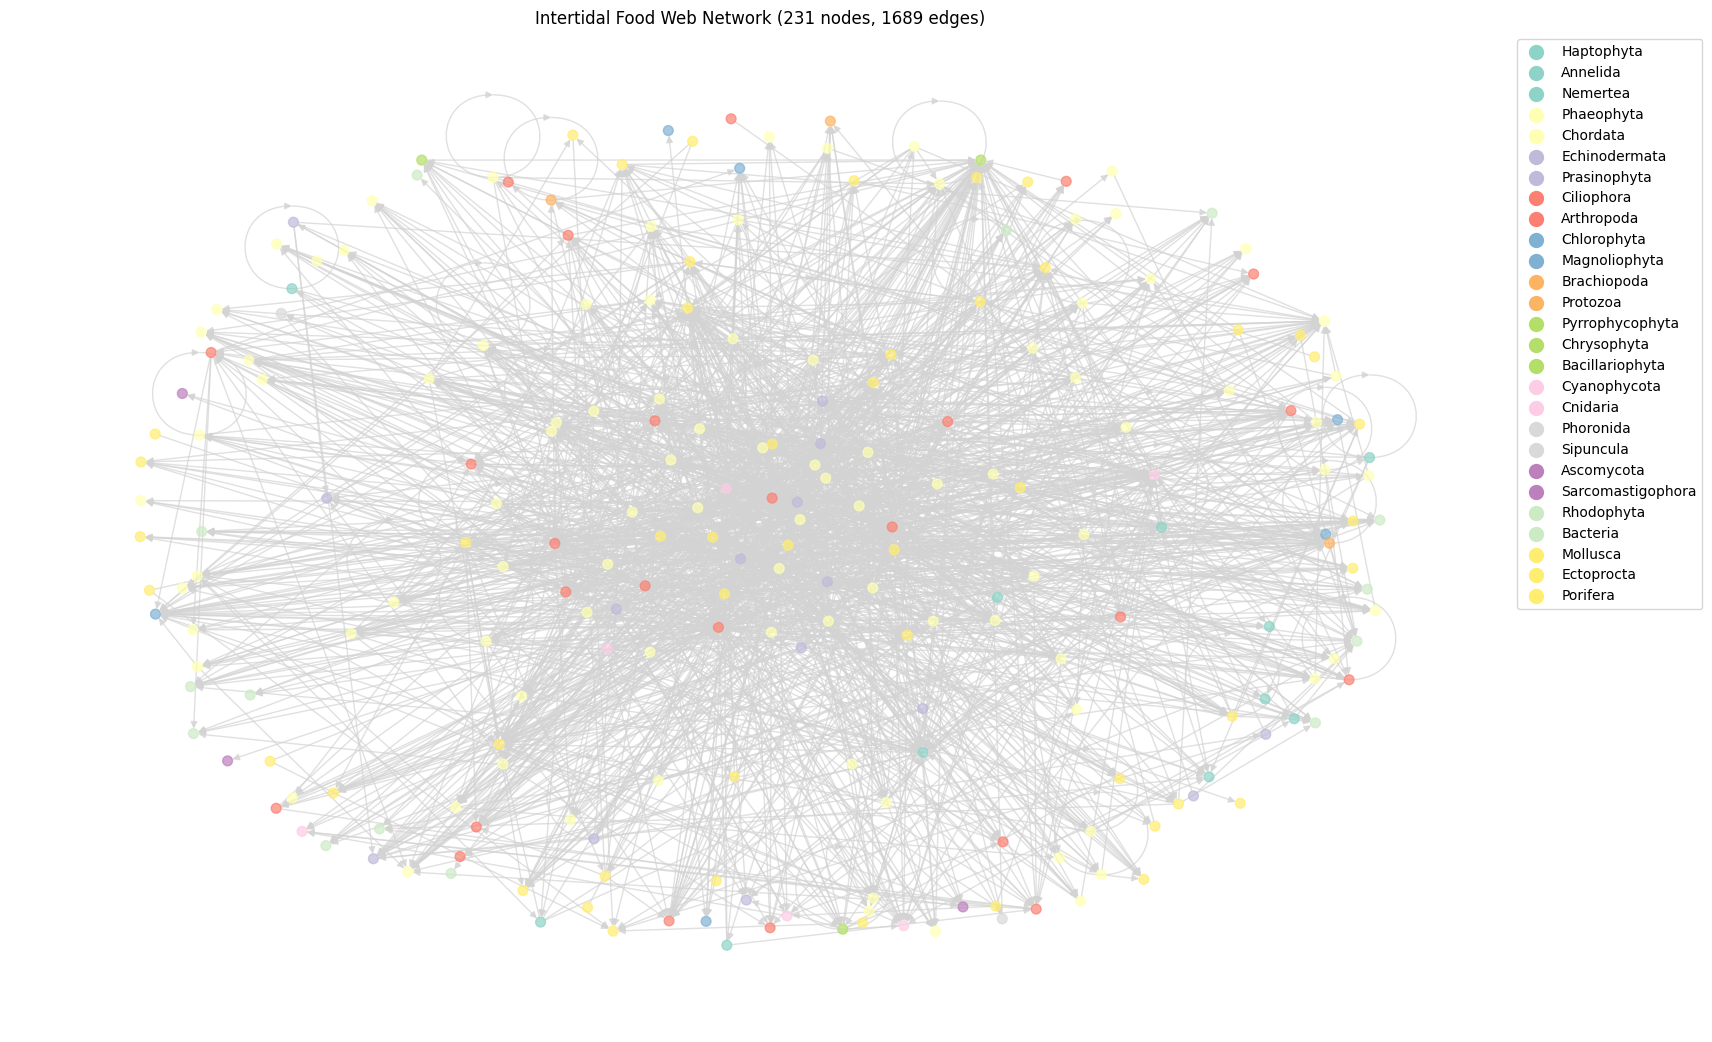

In [17]:
#using the graph filter only the intertidal links
#filter edges directly from G based on edge attributes
intertidal_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get("Intertidal") == True]
#create subgraph
intertidal_G = G.edge_subgraph(intertidal_edges)

#visualize the intertidal graph with better layout and styling
plt.figure(figsize=(15, 10))

# Use spring layout for better positioning
pos = nx.spring_layout(intertidal_G, k=1, iterations=50)

# Draw nodes with different colors based on phylum
phyla = [intertidal_G.nodes[node].get('Phylum', 'Unknown') for node in intertidal_G.nodes()]
unique_phyla = list(set(phyla))
colors = plt.cm.Set3(np.linspace(0, 1, len(unique_phyla)))
phylum_colors = dict(zip(unique_phyla, colors))
node_colors = [phylum_colors.get(intertidal_G.nodes[node].get('Phylum', 'Unknown'), 'gray') for node in intertidal_G.nodes()]

# Draw the graph
nx.draw(intertidal_G, pos, 
        node_color=node_colors,
        node_size=50,
        with_labels=False,  
        edge_color='lightgray',
        alpha=0.7,
        arrows=True,
        arrowsize=10)

# Add legend for phyla
legend_elements = [plt.scatter([], [], c=color, s=100, label=phylum) for phylum, color in phylum_colors.items()]
plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))

plt.title(f'Intertidal Food Web Network ({intertidal_G.number_of_nodes()} nodes, {intertidal_G.number_of_edges()} edges)')
plt.tight_layout()
plt.show()


In [18]:
# Create nearshore subgraph
nearshore_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get("Nearshore") == True]
nearshore_G = G.edge_subgraph(nearshore_edges)

print(f"Nearshore graph created: {nearshore_G.number_of_nodes()} nodes, {nearshore_G.number_of_edges()} edges")


Nearshore graph created: 513 nodes, 6774 edges


In [19]:
#iterate through edges 
both=0
one=0
for edge in G.edges(data=True):
    #check if both nodes are intertidal and nearshore
    if G.nodes[edge[0]]["Intertidal"] and G.nodes[edge[0]]["Nearshore"] and G.nodes[edge[1]]["Intertidal"] and G.nodes[edge[1]]["Nearshore"]:
        #if the edge is both intertidal and nearshore add 1 to both
        if edge[2]["Intertidal"] and edge[2]["Nearshore"]:
            both+=1
            # print(edge)
            # print(G.nodes[edge[0]])
            # print(G.nodes[edge[1]])
        else:
            one+=1
print(both)
print(one)


1546
0


This means that the Graph `G` is non-directional.

In [20]:
#print all Phylum names ONCE 
phylum_names = set()
for node in G.nodes():
    phylum = G.nodes[node].get('Phylum', 'Unknown')
    phylum_names.add(phylum)
    #if the phylum is unknown or nan print it
for phylum in phylum_names:
    print(phylum)




Haptophyta
Annelida
Acanthocephala
Nemertea
Phaeophyta
Chordata
nan
Echinodermata
Prasinophyta
Ciliophora
Arthropoda
Nemata
Chlorophyta
Magnoliophyta
Brachiopoda
Protozoa
Pyrrophycophyta
Chrysophyta
Bacillariophyta
Echiura
Cyanophycota
Cnidaria
Phoronida
Chaetognatha
Sipuncula
Ascomycota
Sarcomastigophora
Rhodophyta
Bacteria
Mollusca
Platyhelminthes
Ectoprocta
Porifera


In [21]:
# Check for nodes with missing phylum information
print("Checking for nodes with missing phylum information:")
nan_phylum_nodes = []
for node in G.nodes():
    phylum = G.nodes[node].get('Phylum', 'Unknown')
    if pd.isna(phylum) or phylum == 'nan' or phylum == '':
        nan_phylum_nodes.append(node)

print(f"Found {len(nan_phylum_nodes)} nodes with missing phylum information:")
for i, node in enumerate(nan_phylum_nodes[:10]):  # Show first 10
    node_data = G.nodes[node]
    print(f"  {i+1}. TSN: {node_data.get('TSN', 'N/A')}, Name: {node_data.get('Name', 'N/A')}")

if len(nan_phylum_nodes) > 10:
    print(f"  ... and {len(nan_phylum_nodes) - 10} more nodes")

# Show statistics about phylum distribution
print(f"\nPhylum distribution in the network:")
phylum_counts = {}
for node in G.nodes():
    phylum = G.nodes[node].get('Phylum', 'Unknown')
    if pd.isna(phylum) or phylum == 'nan':
        phylum = 'Unknown/Missing'
    phylum_counts[phylum] = phylum_counts.get(phylum, 0) + 1

# Sort by count and show all phyla
sorted_phyla = sorted(phylum_counts.items(), key=lambda x: x[1], reverse=True)
for phylum, count in sorted_phyla:
    print(f"  {phylum}: {count} nodes")

# Show all nodes with 'nan' phylum in detail
if nan_phylum_nodes:
    print(f"\nDetailed view of all {len(nan_phylum_nodes)} nodes with missing phylum:")
    for i, node in enumerate(nan_phylum_nodes):
        node_data = G.nodes[node]
        print(f"  {i+1}. TSN: {node_data.get('TSN', 'N/A')}, Name: {node_data.get('Name', 'N/A')}, Phylum: {node_data.get('Phylum', 'N/A')}")
        print(f"      Intertidal: {node_data.get('Intertidal', 'N/A')}, Nearshore: {node_data.get('Nearshore', 'N/A')}")
        print(f"      In-degree: {G.in_degree(node)}, Out-degree: {G.out_degree(node)}")
        print()


Checking for nodes with missing phylum information:
Found 2 nodes with missing phylum information:
  1. TSN: san272, Name: Biofilm Complex
  2. TSN: san266, Name: Detritus complex

Phylum distribution in the network:
  Chordata: 232 nodes
  Mollusca: 67 nodes
  Arthropoda: 63 nodes
  Annelida: 26 nodes
  Echinodermata: 23 nodes
  Bacillariophyta: 15 nodes
  Rhodophyta: 13 nodes
  Phaeophyta: 12 nodes
  Platyhelminthes: 9 nodes
  Pyrrophycophyta: 9 nodes
  Cnidaria: 9 nodes
  Chlorophyta: 5 nodes
  Nemertea: 4 nodes
  Nemata: 4 nodes
  Porifera: 3 nodes
  Protozoa: 3 nodes
  Unknown/Missing: 2 nodes
  Sarcomastigophora: 2 nodes
  Acanthocephala: 2 nodes
  Ciliophora: 2 nodes
  Prasinophyta: 2 nodes
  Ascomycota: 2 nodes
  Haptophyta: 1 nodes
  Magnoliophyta: 1 nodes
  Cyanophycota: 1 nodes
  Chaetognatha: 1 nodes
  Brachiopoda: 1 nodes
  Sipuncula: 1 nodes
  Echiura: 1 nodes
  Chrysophyta: 1 nodes
  Bacteria: 1 nodes
  Phoronida: 1 nodes
  Ectoprocta: 1 nodes

Detailed view of all 2 nod

### Graph for only Phylum !! Maybe to use !!

In [21]:
# #now we want to make another graph where we group the nodes by their phylum and we make an edge between them if they are connected in the original graph

# # Create a new graph where nodes represent phyla
# phylum_graph = nx.DiGraph()

# # Get all unique phyla from the original graph
# phyla = set()
# for node in G.nodes():
#     phylum = G.nodes[node].get('Phylum', 'Unknown')
#     phyla.add(phylum)

# # Add phylum nodes to the new graph
# for phylum in phyla:
#     phylum_graph.add_node(phylum)

# # Count connections between phyla
# phylum_connections = {}
# for edge in G.edges(data=True):
#     source_node = edge[0]
#     target_node = edge[1]
    
#     source_phylum = G.nodes[source_node].get('Phylum', 'Unknown')
#     target_phylum = G.nodes[target_node].get('Phylum', 'Unknown')
    
#     # Create edge key for the phylum connection
#     edge_key = (source_phylum, target_phylum)
    
#     # Count the number of connections between these phyla
#     if edge_key in phylum_connections:
#         phylum_connections[edge_key] += 1
#     else:
#         phylum_connections[edge_key] = 1

# # Add edges between phyla with weights representing connection counts
# for (source_phylum, target_phylum), count in phylum_connections.items():
#     if source_phylum != target_phylum:  # Don't add self-loops
#         phylum_graph.add_edge(source_phylum, target_phylum, weight=count)

# print(f"Phylum graph has {phylum_graph.number_of_nodes()} nodes and {phylum_graph.number_of_edges()} edges")

# # Create hierarchical layout for the phylum-level network
# plt.figure(figsize=(15, 10))

# # Initialize levels dictionary - always define this outside try block
# levels = {}

# # Calculate hierarchical positions based on trophic levels
# # Use networkx's topological sort to determine hierarchy
# try:
#     # Try to find a topological ordering
#     topo_order = list(nx.topological_sort(phylum_graph))
    
#     # If the graph has cycles, use strongly connected components
#     if len(topo_order) != phylum_graph.number_of_nodes():
#         scc = list(nx.strongly_connected_components(phylum_graph))
#         # Flatten the strongly connected components
#         topo_order = [node for component in scc for node in component]
    
#     # Create hierarchical levels based on connectivity
#     processed = set()
    
#     # Assign levels based on in-degree (trophic level)
#     for node in phylum_graph.nodes():
#         in_degree = phylum_graph.in_degree(node)
#         levels[node] = in_degree
    
#     # Normalize levels to create distinct horizontal layers
#     unique_levels = sorted(set(levels.values()))
#     level_mapping = {level: i for i, level in enumerate(unique_levels)}
    
#     # Create hierarchical positions
#     pos = {}
#     level_counts = {}
    
#     for node in phylum_graph.nodes():
#         level = level_mapping[levels[node]]
#         if level not in level_counts:
#             level_counts[level] = 0
#         pos[node] = (level_counts[level], level)
#         level_counts[level] += 1
    
#     # Adjust spacing between levels
#     for node in pos:
#         pos[node] = (pos[node][0] * 3, pos[node][1] * 4)

# except:
#     # Fallback to spring layout if hierarchical layout fails
#     pos = nx.spring_layout(phylum_graph, k=3, iterations=100)
#     # Still assign levels based on in-degree for coloring
#     for node in phylum_graph.nodes():
#         in_degree = phylum_graph.in_degree(node)
#         levels[node] = in_degree

# # Draw nodes with colors based on hierarchical level
# node_colors = []
# for node in phylum_graph.nodes():
#     level = levels.get(node, 0)
#     # Use a colormap to assign colors based on trophic level
#     color_value = level / max(levels.values()) if levels.values() else 0
#     node_colors.append(color_value)

# # Draw nodes
# nx.draw_networkx_nodes(phylum_graph, pos, 
#                       node_color=node_colors,
#                       cmap=plt.cm.viridis,
#                       node_size=1500,
#                       alpha=0.8,
#                       edgecolors='black',
#                       linewidths=2)

# # Draw edges with thickness proportional to weight
# edges = phylum_graph.edges()
# weights = [phylum_graph[u][v]['weight'] for u, v in edges]

# # Normalize weights for visualization
# if weights:
#     max_weight = max(weights)
#     min_weight = min(weights)
#     if max_weight > min_weight:
#         normalized_weights = [(w - min_weight) / (max_weight - min_weight) * 8 + 1 for w in weights]
#     else:
#         normalized_weights = [3] * len(weights)
# else:
#     normalized_weights = [3]

# # Color edges based on direction (hierarchical flow)
# edge_colors = []
# for u, v in edges:
#     u_level = levels.get(u, 0)
#     v_level = levels.get(v, 0)
#     if u_level < v_level:  # Going up the hierarchy
#         edge_colors.append('red')
#     elif u_level > v_level:  # Going down the hierarchy
#         edge_colors.append('blue')
#     else:  # Same level
#         edge_colors.append('gray')

# nx.draw_networkx_edges(phylum_graph, pos,
#                       width=normalized_weights,
#                       alpha=0.7,
#                       edge_color=edge_colors,
#                       arrows=True,
#                       arrowsize=25,
#                       arrowstyle='->')

# # Add labels with better positioning
# label_pos = {}
# for node, (x, y) in pos.items():
#     label_pos[node] = (x, y - 0.3)  # Offset labels below nodes

# nx.draw_networkx_labels(phylum_graph, label_pos,
#                        font_size=10,
#                        font_weight='bold',
#                        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# # Add colorbar for trophic levels
# sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=max(levels.values())))
# sm.set_array([])
# cbar = plt.colorbar(sm, ax=plt.gca(), shrink=0.8)
# cbar.set_label('Trophic Level (In-degree)', rotation=270, labelpad=20)

# # Add legend for edge colors
# from matplotlib.patches import Patch

# legend_elements = [Patch(facecolor='red', label='Upward flow (lower → higher trophic level)'),
#                   Patch(facecolor='blue', label='Downward flow (higher → lower trophic level)'),
#                   Patch(facecolor='gray', label='Same trophic level')]
# plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.15, 1))

# plt.title('Hierarchical Phylum-Level Food Web Network\n(Edge thickness = connection strength, Colors = trophic flow direction)', 
#           fontsize=14, pad=20)
# plt.axis('off')
# plt.tight_layout()
# plt.show()

# # Print some statistics about phylum connections
# print("\nTop 10 phylum connections (by number of edges):")
# sorted_connections = sorted(phylum_connections.items(), key=lambda x: x[1], reverse=True)
# for i, ((source, target), count) in enumerate(sorted_connections[:10]):
#     print(f"{i+1}. {source} -> {target}: {count} connections")



### Link prediction

#### local similarities.

In [22]:
from sklearn.metrics import roc_curve, roc_auc_score
import random

def directed_jaccard_coefficient(G, u, v):
    """Compute a symmetric Jaccard coefficient using both in- and out-neighbors."""
    neigh_u = set(G.successors(u)) | set(G.predecessors(u))
    neigh_v = set(G.successors(v)) | set(G.predecessors(v))
    if not neigh_u or not neigh_v:
        return 0.0
    return len(neigh_u & neigh_v) / len(neigh_u | neigh_v)


def directed_preferential_attachment(G, u, v):
    """Directed preferential attachment = outdegree(u) * indegree(v)."""
    return G.out_degree(u) * G.in_degree(v)


# Leave-one-out prediction functions
def getPredictionsLeaveOneOutDirectedJaccard(G, n_neg=20):
    """
    Leave-one-out link prediction using directed Jaccard.
    For each removed edge, compute similarity for that edge (positive)
    and n_neg random non-edges (negatives).
    """
    probs, labels = [], []
    nodes = list(G.nodes())
    all_possible_pairs = [(a, b) for a in nodes for b in nodes if a != b]

    for e in list(G.edges()):
        u, v = e
        Gprobed = G.copy()
        Gprobed.remove_edge(u, v)

        p_pos = directed_jaccard_coefficient(Gprobed, u, v)
        probs.append(p_pos)
        labels.append(1)

        non_edges = [(a, b) for (a, b) in all_possible_pairs if not Gprobed.has_edge(a, b)]

        if not non_edges:
            continue  

        sampled_non_edges = random.sample(non_edges, min(n_neg, len(non_edges)))
        for (a, b) in sampled_non_edges:
            p_neg = directed_jaccard_coefficient(Gprobed, a, b)
            probs.append(p_neg)
            labels.append(0)

    return probs, labels


def getPredictionsLeaveOneOutDirectedPA(G, n_neg=20):
    """
    Leave-one-out link prediction using directed preferential attachment.
    For each removed edge, compute the score for that edge (positive)
    and n_neg random non-edges (negatives).
    """
    probs, labels = [], []
    nodes = list(G.nodes())

    for e in list(G.edges()):
        u, v = e
        Gprobed = G.copy()
        Gprobed.remove_edge(u, v)

        p_pos = directed_preferential_attachment(Gprobed, u, v)
        probs.append(p_pos)
        labels.append(1)

        non_edges = set()
        while len(non_edges) < n_neg:
            a, b = random.sample(nodes, 2)
            if not Gprobed.has_edge(a, b):
                non_edges.add((a, b))

        for (a, b) in non_edges:
            p_neg = directed_preferential_attachment(Gprobed, a, b)
            probs.append(p_neg)
            labels.append(0)

    return probs, labels


# Leave-k-out prediction functions
def getPredictionsLeaveKOutDirectedJaccard(G, k=5, n_neg=5):
    """
    Iterates over the entire graph, removing k edges at a time.
    For each batch:
      - compute directed Jaccard for the k removed edges (positives)
      - sample n_neg * k random non-edges as negatives.
    Returns full lists of probs and labels for all batches.
    """
    probs, labels = [], []
    edges = list(G.edges())
    nodes = list(G.nodes())
    all_pairs = [(a, b) for a in nodes for b in nodes if a != b]

    random.shuffle(edges)
    batches = [edges[i:i+k] for i in range(0, len(edges), k)]

    for batch_edges in batches:
        Gprobed = G.copy()
        Gprobed.remove_edges_from(batch_edges)

        for (u, v) in batch_edges:
            p = directed_jaccard_coefficient(Gprobed, u, v)
            probs.append(p)
            labels.append(1)

        non_edges = [(a, b) for (a, b) in all_pairs if not Gprobed.has_edge(a, b)]
        if len(non_edges) == 0:
            continue
        n_neg_total = min(len(non_edges), n_neg * len(batch_edges))
        sampled_neg = random.sample(non_edges, n_neg_total)

        for (a, b) in sampled_neg:
            p = directed_jaccard_coefficient(Gprobed, a, b)
            probs.append(p)
            labels.append(0)

    return probs, labels


def getPredictionsLeaveKOutDirectedPA(G, k=5, n_neg=5):
    """
    Leave-k-out link prediction using directed preferential attachment.
    """
    probs, labels = [], []
    edges = list(G.edges())
    nodes = list(G.nodes())
    all_pairs = [(a, b) for a in nodes for b in nodes if a != b]

    random.shuffle(edges)
    batches = [edges[i:i+k] for i in range(0, len(edges), k)]

    for batch_edges in batches:
        Gprobed = G.copy()
        Gprobed.remove_edges_from(batch_edges)

        for (u, v) in batch_edges:
            p = directed_preferential_attachment(Gprobed, u, v)
            probs.append(p)
            labels.append(1)

        non_edges = [(a, b) for (a, b) in all_pairs if not Gprobed.has_edge(a, b)]
        if len(non_edges) == 0:
            continue
        n_neg_total = min(len(non_edges), n_neg * len(batch_edges))
        sampled_neg = random.sample(non_edges, n_neg_total)

        for (a, b) in sampled_neg:
            p = directed_preferential_attachment(Gprobed, a, b)
            probs.append(p)
            labels.append(0)

    return probs, labels

print("Link prediction functions defined successfully!")

Link prediction functions defined successfully!


##### This is the custom similarity

In [23]:
#link prediction using new similarity method
#auxilarry function to check if u and v can meet intertidal or nearshore 
def can_meet(G, u, v):
    if G.nodes[u]["Intertidal"] and G.nodes[v]["Intertidal"]:
        return 1
    elif G.nodes[u]["Nearshore"] and G.nodes[v]["Nearshore"]:
        return 1
    else:
        return 0

        
def similarity(G, u, v):
   #check if u and v can meet intertidal or nearshore 
   if can_meet(G, u, v) == 0:
    return 0
   else:
    # get the prey of u (what u eats - u's successors since edge is Consumer->Resource)
    prey_u = set(G.successors(u))
    # get the predators of v (what eats v - v's predecessors)
    preds_v = set(G.predecessors(v))
    # get the prey of each predator of v (what v's predators eat)
    prey_of_preds_v = set()
    for pred in preds_v:
        prey_of_preds_v.update(G.successors(pred))
    # find common prey between u's prey and the prey of v's predators
    common_prey = prey_u & prey_of_preds_v
    # define similarity as the Jaccard index between prey_u and prey_of_preds_v
    union_prey = prey_u | prey_of_preds_v
    if len(union_prey) == 0:
        return 0
    else:
        return len(common_prey) / len(union_prey)

##### K-Fold cross validation implementation

In [24]:
# K-Fold Cross-Validation Implementation
def getPredictionsKFold(G, n_folds=5, n_neg=10, similarity_func=directed_jaccard_coefficient):
    """
    K-fold cross-validation for link prediction.
    Splits edges into n_folds, uses each fold as test set once.
    
    Parameters:
    - G: NetworkX DiGraph
    - n_folds: number of folds
    - n_neg: number of negative samples per positive edge
    - similarity_func: function to compute similarity between nodes
    
    Returns:
    - probs: list of predicted probabilities/scores
    - labels: list of true labels (1 for real edges, 0 for non-edges)
    """
    probs, labels = [], []
    edges = list(G.edges())
    nodes = list(G.nodes())
    
    # Shuffle edges for random splits
    random.shuffle(edges)
    
    # Split edges into folds
    fold_size = len(edges) // n_folds
    folds = [edges[i*fold_size:(i+1)*fold_size] for i in range(n_folds)]
    # Add remaining edges to last fold
    if len(edges) % n_folds != 0:
        folds[-1].extend(edges[n_folds*fold_size:])
    
    print(f"Running {n_folds}-fold cross-validation...")
    print(f"Total edges: {len(edges)}, Fold sizes: {[len(f) for f in folds]}")
    
    for fold_idx, test_edges in enumerate(folds):
        print(f"  Processing fold {fold_idx + 1}/{n_folds}...", end=" ")
        
        # Create training graph (remove test edges)
        G_train = G.copy()
        G_train.remove_edges_from(test_edges)
        
        # Evaluate on test edges (positives)
        for u, v in test_edges:
            if G_train.has_node(u) and G_train.has_node(v):
                score = similarity_func(G_train, u, v)
                probs.append(score)
                labels.append(1)
        
        # Sample negative edges
        all_possible_pairs = [(a, b) for a in nodes for b in nodes if a != b]
        non_edges = [(a, b) for (a, b) in all_possible_pairs if not G.has_edge(a, b)]
        
        if non_edges:
            n_neg_total = min(len(non_edges), n_neg * len(test_edges))
            sampled_non_edges = random.sample(non_edges, n_neg_total)
            
            for a, b in sampled_non_edges:
                if G_train.has_node(a) and G_train.has_node(b):
                    score = similarity_func(G_train, a, b)
                    probs.append(score)
                    labels.append(0)
        
        print(f"Done ({len(test_edges)} pos, {n_neg_total if non_edges else 0} neg)")
    
    return probs, labels


def getPredictionsKFoldPA(G, n_folds=5, n_neg=10):
    """K-fold cross-validation using Preferential Attachment."""
    probs, labels = [], []
    edges = list(G.edges())
    nodes = list(G.nodes())
    
    random.shuffle(edges)
    fold_size = len(edges) // n_folds
    folds = [edges[i*fold_size:(i+1)*fold_size] for i in range(n_folds)]
    if len(edges) % n_folds != 0:
        folds[-1].extend(edges[n_folds*fold_size:])
    
    print(f"Running {n_folds}-fold cross-validation (Preferential Attachment)...")
    
    for fold_idx, test_edges in enumerate(folds):
        print(f"  Processing fold {fold_idx + 1}/{n_folds}...", end=" ")
        
        G_train = G.copy()
        G_train.remove_edges_from(test_edges)
        
        for u, v in test_edges:
            if G_train.has_node(u) and G_train.has_node(v):
                score = directed_preferential_attachment(G_train, u, v)
                probs.append(score)
                labels.append(1)
        
        non_edges = set()
        attempts = 0
        max_attempts = n_neg * len(test_edges) * 10
        while len(non_edges) < n_neg * len(test_edges) and attempts < max_attempts:
            a, b = random.choice(nodes), random.choice(nodes)
            if a != b and not G.has_edge(a, b):
                non_edges.add((a, b))
            attempts += 1
        
        for a, b in non_edges:
            if G_train.has_node(a) and G_train.has_node(b):
                score = directed_preferential_attachment(G_train, a, b)
                probs.append(score)
                labels.append(0)
        
        print(f"Done ({len(test_edges)} pos, {len(non_edges)} neg)")
    
    return probs, labels


def getPredictionsKFoldCustom(G, n_folds=5, n_neg=10):
    """K-fold cross-validation using custom similarity function."""
    probs, labels = [], []
    edges = list(G.edges())
    nodes = list(G.nodes())
    
    random.shuffle(edges)
    fold_size = len(edges) // n_folds
    folds = [edges[i*fold_size:(i+1)*fold_size] for i in range(n_folds)]
    if len(edges) % n_folds != 0:
        folds[-1].extend(edges[n_folds*fold_size:])
    
    print(f"Running {n_folds}-fold cross-validation (Custom Similarity)...")
    
    for fold_idx, test_edges in enumerate(folds):
        print(f"  Processing fold {fold_idx + 1}/{n_folds}...", end=" ")
        
        G_train = G.copy()
        G_train.remove_edges_from(test_edges)
        
        for u, v in test_edges:
            if G_train.has_node(u) and G_train.has_node(v):
                score = similarity(G_train, u, v)
                probs.append(score)
                labels.append(1)
        
        non_edges = set()
        attempts = 0
        max_attempts = n_neg * len(test_edges) * 10
        while len(non_edges) < n_neg * len(test_edges) and attempts < max_attempts:
            a, b = random.choice(nodes), random.choice(nodes)
            if a != b and not G.has_edge(a, b):
                non_edges.add((a, b))
            attempts += 1
        
        for a, b in non_edges:
            if G_train.has_node(a) and G_train.has_node(b):
                score = similarity(G_train, a, b)
                probs.append(score)
                labels.append(0)
        
        print(f"Done ({len(test_edges)} pos, {len(non_edges)} neg)")
    
    return probs, labels


print("K-Fold cross-validation functions defined successfully!") 


K-Fold cross-validation functions defined successfully!


In [25]:
# Define Leave-One-Out with Custom Similarity Function
def getPredictionsLeaveOneOutCustom(G, n_neg=20):
    """
    Leave-one-out link prediction using custom similarity function.
    For each removed edge, compute similarity for that edge (positive)
    and n_neg random non-edges (negatives).
    """
    probs, labels = [], []
    nodes = list(G.nodes())
    all_possible_pairs = [(a, b) for a in nodes for b in nodes if a != b]

    for e in list(G.edges()):
        u, v = e
        Gprobed = G.copy()
        Gprobed.remove_edge(u, v)

        p_pos = similarity(Gprobed, u, v)
        probs.append(p_pos)
        labels.append(1)

        non_edges = [(a, b) for (a, b) in all_possible_pairs if not Gprobed.has_edge(a, b)]

        if not non_edges:
            continue  

        sampled_non_edges = random.sample(non_edges, min(n_neg, len(non_edges)))
        for (a, b) in sampled_non_edges:
            p_neg = similarity(Gprobed, a, b)
            probs.append(p_neg)
            labels.append(0)

    return probs, labels


print("Leave-one-out with custom similarity function defined!")


Leave-one-out with custom similarity function defined!


#### global similarities

#### Three global similarity metrics

Can refer here for small explainations for the metrics: https://cran.r-project.org/web/packages/linkprediction/vignettes/proxfun.html#average-commute-time 

In [43]:
import numpy as np
import networkx as nx
from scipy.linalg import pinv


def average_commute_time_index(G):
    """
    Computes the Average Commute Time similarity for all node pairs.
    Returns a dictionary {(u,v): similarity}.
    Note: G can be directed, but Laplacian is symmetrized.
    """

    A = nx.to_numpy_array(G)
    A_sym = (A + A.T) / 2
    
    D = np.diag(A_sym.sum(axis=1))

    L = D - A_sym
    
    # Pseudoinverse of Laplacian
    L_pinv = pinv(L)
    
    nodes = list(G.nodes())
    sim = {}
    for i, u in enumerate(nodes):
        for j, v in enumerate(nodes):
            if u != v:
                # Commute time: ACT(u,v) = vol(G) * (L^+_uu + L^+_vv - 2*L^+_uv)
                vol = G.number_of_edges() * 2  # Since *unweighted* version
                commute_time = vol * (L_pinv[i, i] + L_pinv[j, j] - 2*L_pinv[i, j])
                sim[(u, v)] = 1 / (1 + commute_time)
    return sim


def matrix_forest_index(G, alpha=0.01):
    """
    Computes Matrix Forest Index similarity for all node pairs.
    F = (I + alpha * L)^-1
    """
    A = nx.to_numpy_array(G)
    A_sym = (A + A.T) / 2
    
    # Degree matrix
    D = np.diag(A_sym.sum(axis=1))
    
    # Laplacian
    L = D - A_sym
    
    # Compute (I + alpha * L)^-1
    I = np.eye(L.shape[0])
    F = np.linalg.inv(I + alpha * L)
    
    nodes = list(G.nodes())
    sim = {}
    for i, u in enumerate(nodes):
        for j, v in enumerate(nodes):
            if u != v:
                sim[(u, v)] = F[i, j]
    return sim


def leicht_holme_newman_index(G):
    """
    Computes LHN index for all node pairs.
    LHN(u,v) = |Gamma(u) ∩ Gamma(v)| / (k_u * k_v)
    """
    nodes = list(G.nodes())
    sim = {}
    
    neighbors = {n: set(G.successors(n)) | set(G.predecessors(n)) for n in nodes}
    degrees = {n: len(neighbors[n]) for n in nodes}
    
    for u in nodes:
        for v in nodes:
            if u != v:
                inter = len(neighbors[u] & neighbors[v])
                denom = degrees[u] * degrees[v]
                sim[(u, v)] = inter / denom if denom != 0 else 0.0
    return sim


tried a complicated global metric which - normalised average commute time

In [34]:
# import numpy as np
# import networkx as nx
# from scipy.linalg import pinv
# from sklearn.metrics import roc_curve, roc_auc_score
# import matplotlib.pyplot as plt
# from tqdm import tqdm

# def compute_stationary_distribution(G):
#     """
#     Compute the stationary distribution π for a graph G.
#     π(x) = k_x / Σ_y k_y where k_x is the degree of node x.
#     For directed graphs, uses total degree (in + out).
#     """
#     if G.is_directed():
#         degrees = {node: G.in_degree(node) + G.out_degree(node) for node in G.nodes()}
#     else:
#         degrees = dict(G.degree())
    
#     total_degree = sum(degrees.values())
#     if total_degree == 0:
#         return {node: 1.0 / len(G) for node in G.nodes()}
    
#     pi = {node: deg / total_degree for node, deg in degrees.items()}
#     return pi

# def compute_commute_time_matrix(G):
#     """
#     Compute the average commute time matrix m(x,y) for all pairs of nodes.
#     For directed graphs, converts to undirected for commute time calculation.
#     """
#     # Convert to undirected for commute time (standard approach)
#     G_undirected = G.to_undirected() if G.is_directed() else G
    
#     # Check connectivity
#     if not nx.is_connected(G_undirected):
#         # Get largest connected component
#         largest_cc = max(nx.connected_components(G_undirected), key=len)
#         G_undirected = G_undirected.subgraph(largest_cc).copy()
    
#     nodes = list(G_undirected.nodes())
#     node_to_idx = {node: i for i, node in enumerate(nodes)}
#     n = len(nodes)
    
#     # Compute Laplacian matrix
#     L = nx.laplacian_matrix(G_undirected, nodelist=nodes).toarray()
    
#     # Compute Moore-Penrose pseudoinverse
#     L_pinv = pinv(L)
    
#     # Volume of the graph
#     vol_G = sum(dict(G_undirected.degree()).values())
    
#     # Compute commute time matrix
#     m = np.zeros((n, n))
#     for i in range(n):
#         for j in range(n):
#             if i != j:
#                 m[i, j] = vol_G * (L_pinv[i, i] + L_pinv[j, j] - 2 * L_pinv[i, j])
    
#     return m, node_to_idx

# def normalized_average_commute_time(G, x, y, m_matrix, pi, node_to_idx):
#     """
#     Compute NACT similarity: s_xy = 1 / (m(x,y)/π_y + m(y,x)/π_x)
#     """
#     if x not in node_to_idx or y not in node_to_idx:
#         return 0.0
    
#     i = node_to_idx[x]
#     j = node_to_idx[y]
    
#     m_xy = m_matrix[i, j]
#     m_yx = m_matrix[j, i]
    
#     denominator = m_xy / pi[y] + m_yx / pi[x]
    
#     if denominator == 0 or not np.isfinite(denominator):
#         return 0.0
    
#     score = 1.0 / denominator
#     return score if np.isfinite(score) else 0.0

# def getPredictionsKFoldNACT(G, k=5, n_neg=10, seed=42):
#     """
#     K-fold cross-validation link prediction using NACT similarity.
#     Much more efficient than leave-one-out.
    
#     Parameters:
#     -----------
#     G : networkx.DiGraph
#         Directed graph
#     k : int
#         Number of folds for cross-validation
#     n_neg : int
#         Number of negative samples per positive edge
#     seed : int
#         Random seed for reproducibility
        
#     Returns:
#     --------
#     probs : list
#         Predicted scores (NACT similarities)
#     labels : list
#         True labels (1 for real edges, 0 for non-edges)
#     """
#     np.random.seed(seed)
    
#     probs = []
#     labels = []
    
#     edges = list(G.edges())
#     nodes = list(G.nodes())
#     n_edges = len(edges)
    
#     np.random.shuffle(edges)
    
#     fold_size = n_edges // k
    
#     print(f"Processing {n_edges} edges with {k}-fold CV...")
    
#     for fold_idx in range(k):
#         print(f"\nFold {fold_idx + 1}/{k}")
        
#         # Define test set for this fold
#         start_idx = fold_idx * fold_size
#         end_idx = start_idx + fold_size if fold_idx < k - 1 else n_edges
#         test_edges = edges[start_idx:end_idx]
        
#         # Create training graph (remove test edges)
#         G_train = G.copy()
#         G_train.remove_edges_from(test_edges)
        
#         # Precompute NACT components once per fold (more efficient!)
#         try:
#             m_matrix, node_to_idx = compute_commute_time_matrix(G_train)
#             pi = compute_stationary_distribution(G_train)
#         except Exception as e:
#             print(f"Warning: Error computing NACT components for fold {fold_idx}: {e}")
#             continue
        
#         # Evaluate on test edges (positive samples)
#         for u, v in tqdm(test_edges, desc=f"Fold {fold_idx + 1} - Test edges"):
#             score_pos = normalized_average_commute_time(G_train, u, v, m_matrix, pi, node_to_idx)
#             probs.append(score_pos)
#             labels.append(1)
        
#         # Sample negative edges for this fold
#         n_neg_total = len(test_edges) * n_neg
#         neg_samples = 0
#         attempts = 0
#         max_attempts = n_neg_total * 100
        
#         print(f"Sampling {n_neg_total} negative samples...")
#         while neg_samples < n_neg_total and attempts < max_attempts:
#             attempts += 1
#             node_u = np.random.choice(nodes)
#             node_v = np.random.choice(nodes)
            
#             if node_u != node_v and not G.has_edge(node_u, node_v):
#                 score_neg = normalized_average_commute_time(G_train, node_u, node_v, m_matrix, pi, node_to_idx)
#                 probs.append(score_neg)
#                 labels.append(0)
#                 neg_samples += 1
    
#     return probs, labels

##### K-Fold cross validation for global similarities.

In [37]:
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score
from tqdm import tqdm
import random

def getPredictionsKFoldGlobal(G, similarity_dict_func, k=5, n_neg=10, seed=42):
    """
    K-fold cross-validation for link prediction using a global similarity metric.
    
    Parameters
    ----------
    G : networkx.DiGraph
        The input directed graph.
    similarity_dict_func : function
        A function that takes G and returns {(u,v): similarity} for all pairs.
    k : int
        Number of folds.
    n_neg : int
        Number of negative samples per positive edge.
    seed : int
        Random seed.
    
    Returns
    -------
    probs : list
        Predicted similarity scores.
    labels : list
        True labels (1 for real edges, 0 for sampled non-edges).
    """
    random.seed(seed)
    np.random.seed(seed)
    
    edges = list(G.edges())
    nodes = list(G.nodes())
    n_edges = len(edges)
    np.random.shuffle(edges)
    
    fold_size = n_edges // k
    folds = [edges[i*fold_size:(i+1)*fold_size] for i in range(k)]
    if len(edges) % k != 0:
        folds[-1].extend(edges[k*fold_size:])
    
    print(f"Processing {n_edges} edges with {k}-fold CV...")
    
    probs = []
    labels = []
    
    for fold_idx, test_edges in enumerate(folds):
        print(f"\nFold {fold_idx+1}/{k}")
        
        G_train = G.copy()
        G_train.remove_edges_from(test_edges)
        
        sim_dict = similarity_dict_func(G_train)
        
        # Positive samples (test edges)
        for u, v in tqdm(test_edges, desc=f"Fold {fold_idx+1} - Test edges"):
            score = sim_dict.get((u,v), 0.0)
            probs.append(score)
            labels.append(1)
        
        n_neg_total = len(test_edges) * n_neg
        neg_samples = 0
        attempts = 0
        max_attempts = n_neg_total * 100
        while neg_samples < n_neg_total and attempts < max_attempts:
            attempts += 1
            u, v = random.choice(nodes), random.choice(nodes)
            if u != v and not G.has_edge(u, v):
                score = sim_dict.get((u,v), 0.0)
                probs.append(score)
                labels.append(0)
                neg_samples += 1
    
    return probs, labels

## Actually running the models

### Running Local similarity

#### running on big graph.

In [ ]:
# Link prediction on the full species-level graph with custom similarity (G)
print("Running link prediction on full species-level graph with custom similarity...")
print(f"Full graph G: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print("Note: This may take a while due to the large graph size...")

probs_j_full, labels_j_full = getPredictionsLeaveOneOutDirectedJaccard(G, n_neg=10)
probs_pa_full, labels_pa_full = getPredictionsLeaveOneOutDirectedPA(G, n_neg=10)
probs_custom_full, labels_custom_full = getPredictionsLeaveOneOutCustom(G, n_neg=10)

fpr_j_full, tpr_j_full, _ = roc_curve(labels_j_full, probs_j_full)
fpr_pa_full, tpr_pa_full, _ = roc_curve(labels_pa_full, probs_pa_full)
fpr_custom_full, tpr_custom_full, _ = roc_curve(labels_custom_full, probs_custom_full)

auc_j_full = roc_auc_score(labels_j_full, probs_j_full)
auc_pa_full = roc_auc_score(labels_pa_full, probs_pa_full)
auc_custom_full = roc_auc_score(labels_custom_full, probs_custom_full)

plt.figure(figsize=(8, 8))
plt.plot(fpr_j_full, tpr_j_full, "-.", label=f"Directed Jaccard (AUC={auc_j_full:.3f})", color="purple", linewidth=2)
plt.plot(fpr_pa_full, tpr_pa_full, "-", label=f"Directed Pref. Attach. (AUC={auc_pa_full:.3f})", color="orange", linewidth=2)
plt.plot(fpr_custom_full, tpr_custom_full, "--", label=f"Custom Similarity (AUC={auc_custom_full:.3f})", color="green", linewidth=2)
plt.plot([0, 1], [0, 1], "--k", label="Random chance")

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves for Link Prediction (Leave-One-Out)\nFull Species-Level Food Web", fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC (Directed Jaccard): {auc_j_full:.4f}")
print(f"AUC (Directed Preferential Attachment): {auc_pa_full:.4f}")
print(f"AUC (Custom Similarity): {auc_custom_full:.4f}")


Running link prediction on full species-level graph with custom similarity...
Full graph G: 520 nodes, 6917 edges
Note: This may take a while due to the large graph size...


KeyboardInterrupt: 

#### running on only intertidal

Running link prediction on intertidal subgraph with custom similarity...
Intertidal graph: 231 nodes, 1689 edges


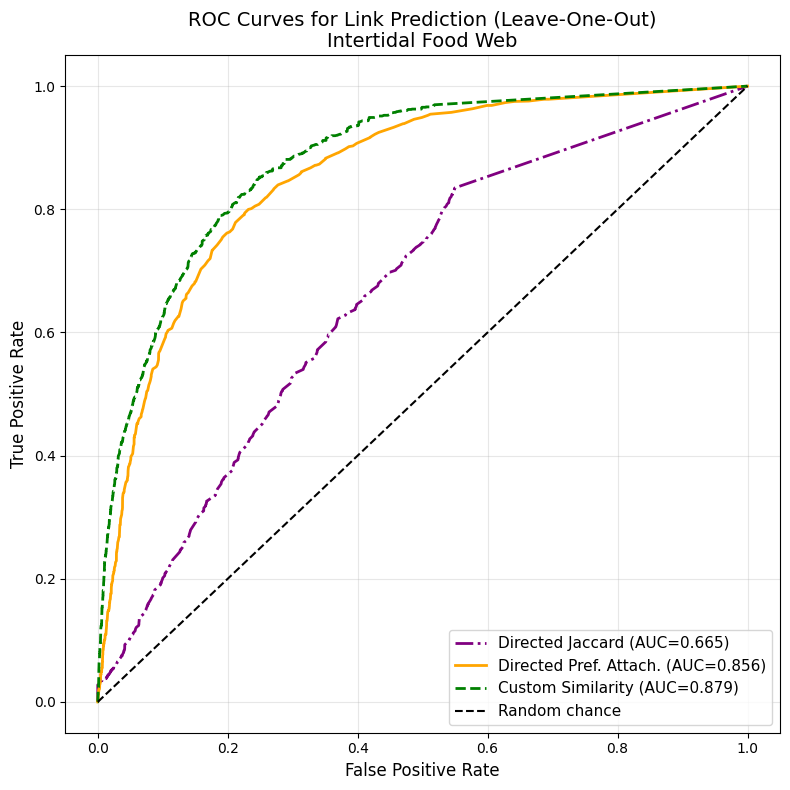

AUC (Directed Jaccard): 0.6648
AUC (Directed Preferential Attachment): 0.8558
AUC (Custom Similarity): 0.8793


In [ ]:
# Link prediction on intertidal subgraph with custom similarity
print("Running link prediction on intertidal subgraph with custom similarity...")
print(f"Intertidal graph: {intertidal_G.number_of_nodes()} nodes, {intertidal_G.number_of_edges()} edges")

probs_j_int, labels_j_int = getPredictionsLeaveOneOutDirectedJaccard(intertidal_G, n_neg=10)
probs_pa_int, labels_pa_int = getPredictionsLeaveOneOutDirectedPA(intertidal_G, n_neg=10)
probs_custom_int, labels_custom_int = getPredictionsLeaveOneOutCustom(intertidal_G, n_neg=10)

fpr_j_int, tpr_j_int, _ = roc_curve(labels_j_int, probs_j_int)
fpr_pa_int, tpr_pa_int, _ = roc_curve(labels_pa_int, probs_pa_int)
fpr_custom_int, tpr_custom_int, _ = roc_curve(labels_custom_int, probs_custom_int)

auc_j_int = roc_auc_score(labels_j_int, probs_j_int)
auc_pa_int = roc_auc_score(labels_pa_int, probs_pa_int)
auc_custom_int = roc_auc_score(labels_custom_int, probs_custom_int)

plt.figure(figsize=(8, 8))
plt.plot(fpr_j_int, tpr_j_int, "-.", label=f"Directed Jaccard (AUC={auc_j_int:.3f})", color="purple", linewidth=2)
plt.plot(fpr_pa_int, tpr_pa_int, "-", label=f"Directed Pref. Attach. (AUC={auc_pa_int:.3f})", color="orange", linewidth=2)
plt.plot(fpr_custom_int, tpr_custom_int, "--", label=f"Custom Similarity (AUC={auc_custom_int:.3f})", color="green", linewidth=2)
plt.plot([0, 1], [0, 1], "--k", label="Random chance")

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves for Link Prediction (Leave-One-Out)\nIntertidal Food Web", fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC (Directed Jaccard): {auc_j_int:.4f}")
print(f"AUC (Directed Preferential Attachment): {auc_pa_int:.4f}")
print(f"AUC (Custom Similarity): {auc_custom_int:.4f}")


#### running on only nearshore.

Running link prediction on nearshore subgraph with custom similarity...
Nearshore graph: 513 nodes, 6774 edges
Running 5-fold cross-validation...
Total edges: 6774, Fold sizes: [1354, 1354, 1354, 1354, 1358]
  Processing fold 1/5... Done (1354 pos, 13540 neg)
  Processing fold 2/5... Done (1354 pos, 13540 neg)
  Processing fold 3/5... Done (1354 pos, 13540 neg)
  Processing fold 4/5... Done (1354 pos, 13540 neg)
  Processing fold 5/5... Done (1358 pos, 13580 neg)
Running 5-fold cross-validation (Preferential Attachment)...
  Processing fold 1/5... Done (1354 pos, 13540 neg)
  Processing fold 2/5... Done (1354 pos, 13540 neg)
  Processing fold 3/5... Done (1354 pos, 13540 neg)
  Processing fold 4/5... Done (1354 pos, 13540 neg)
  Processing fold 5/5... Done (1358 pos, 13580 neg)
Running 5-fold cross-validation (Custom Similarity)...
  Processing fold 1/5... Done (1354 pos, 13540 neg)
  Processing fold 2/5... Done (1354 pos, 13540 neg)
  Processing fold 3/5... Done (1354 pos, 13540 neg)


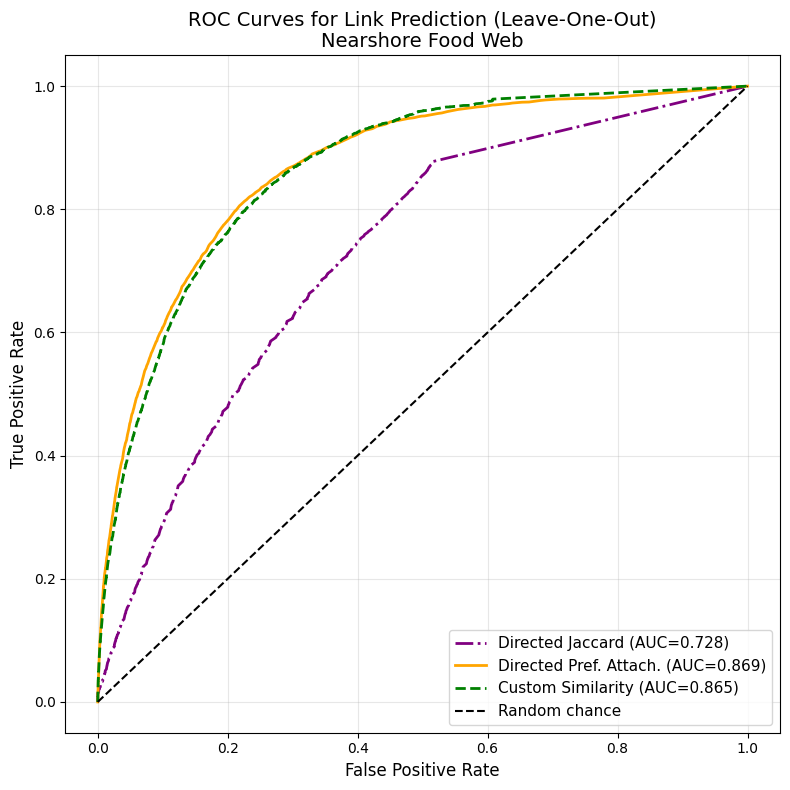

AUC (Directed Jaccard): 0.7277
AUC (Directed Preferential Attachment): 0.8688
AUC (Custom Similarity): 0.8655


In [29]:
# Link prediction on nearshore subgraph with custom similarity
print("Running link prediction on nearshore subgraph with custom similarity...")
print(f"Nearshore graph: {nearshore_G.number_of_nodes()} nodes, {nearshore_G.number_of_edges()} edges")

# probs_j_near, labels_j_near = getPredictionsLeaveOneOutDirectedJaccard(nearshore_G, n_neg=10)
# probs_pa_near, labels_pa_near = getPredictionsLeaveOneOutDirectedPA(nearshore_G, n_neg=10)
# probs_custom_near, labels_custom_near = getPredictionsLeaveOneOutCustom(nearshore_G, n_neg=10)

probs_j_near, labels_j_near = getPredictionsKFold(nearshore_G, n_neg=10)
probs_pa_near, labels_pa_near = getPredictionsKFoldPA(nearshore_G, n_neg=10)
probs_custom_near, labels_custom_near = getPredictionsKFoldCustom(nearshore_G, n_neg=10)

fpr_j_near, tpr_j_near, _ = roc_curve(labels_j_near, probs_j_near)
fpr_pa_near, tpr_pa_near, _ = roc_curve(labels_pa_near, probs_pa_near)
fpr_custom_near, tpr_custom_near, _ = roc_curve(labels_custom_near, probs_custom_near)

auc_j_near = roc_auc_score(labels_j_near, probs_j_near)
auc_pa_near = roc_auc_score(labels_pa_near, probs_pa_near)
auc_custom_near = roc_auc_score(labels_custom_near, probs_custom_near)

plt.figure(figsize=(8, 8))
plt.plot(fpr_j_near, tpr_j_near, "-.", label=f"Directed Jaccard (AUC={auc_j_near:.3f})", color="purple", linewidth=2)
plt.plot(fpr_pa_near, tpr_pa_near, "-", label=f"Directed Pref. Attach. (AUC={auc_pa_near:.3f})", color="orange", linewidth=2)
plt.plot(fpr_custom_near, tpr_custom_near, "--", label=f"Custom Similarity (AUC={auc_custom_near:.3f})", color="green", linewidth=2)
plt.plot([0, 1], [0, 1], "--k", label="Random chance")

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves for Link Prediction (Leave-One-Out)\nNearshore Food Web", fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC (Directed Jaccard): {auc_j_near:.4f}")
print(f"AUC (Directed Preferential Attachment): {auc_pa_near:.4f}")
print(f"AUC (Custom Similarity): {auc_custom_near:.4f}")


### Running Global similarity

#### running on big graph

Running link prediction on full species-level graph with custom similarity...
Full graph G: 520 nodes, 6917 edges
Note: This may take a while due to the large graph size...
Processing 6917 edges with 5-fold CV...

Fold 1/5


Fold 1 - Test edges: 100%|██████████| 1383/1383 [00:00<?, ?it/s]



Fold 2/5


Fold 2 - Test edges: 100%|██████████| 1383/1383 [00:00<?, ?it/s]



Fold 3/5


...

Fold 3 - Test edges: 100%|██████████| 1383/1383 [00:00<00:00, 691880.06it/s]



Fold 4/5


Fold 4 - Test edges: 100%|██████████| 1383/1383 [00:00<?, ?it/s]



Fold 5/5


Fold 5 - Test edges: 100%|██████████| 1385/1385 [00:00<?, ?it/s]


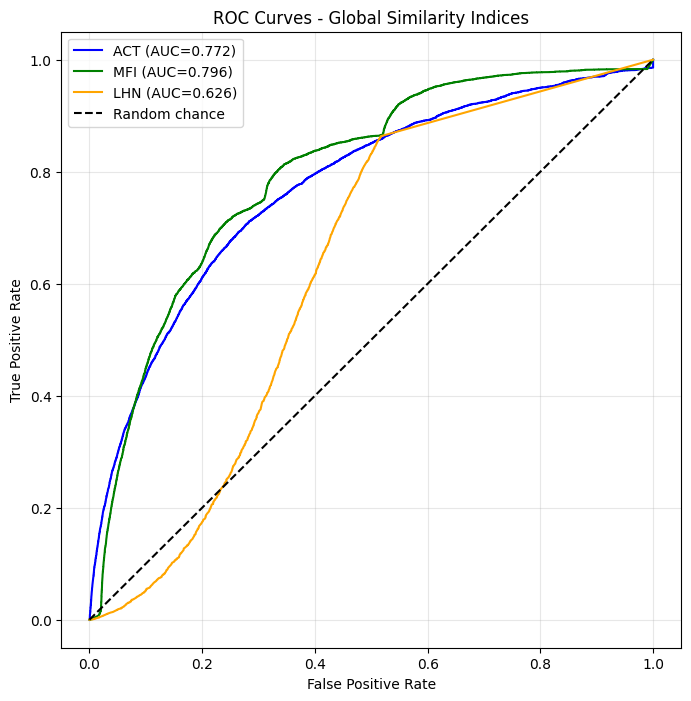

In [47]:
# Link prediction on the full species-level graph with custom similarity (G)
print("Running link prediction on full species-level graph with custom similarity...")
print(f"Full graph G: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print("Note: This may take a while due to the large graph size...")

# Run NACT link prediction with K-fold (recommended) 
probs_act, labels_act = getPredictionsKFoldGlobal(G, average_commute_time_index, k=5, n_neg=10)
probs_mfi, labels_mfi = getPredictionsKFoldGlobal(G, matrix_forest_index, k=5, n_neg=10)
probs_lhn, labels_lhn = getPredictionsKFoldGlobal(G, leicht_holme_newman_index, k=5, n_neg=10)


# Compute ROC and AUC
from sklearn.metrics import roc_curve, roc_auc_score
fpr_act, tpr_act, _ = roc_curve(labels_act, probs_act)
auc_act = roc_auc_score(labels_act, probs_act)

fpr_mfi, tpr_mfi, _ = roc_curve(labels_mfi, probs_mfi)
auc_mfi = roc_auc_score(labels_mfi, probs_mfi)

fpr_lhn, tpr_lhn, _ = roc_curve(labels_lhn, probs_lhn)
auc_lhn = roc_auc_score(labels_lhn, probs_lhn)

# Plot together
import matplotlib.pyplot as plt
plt.figure(figsize=(8,8))
plt.plot(fpr_act, tpr_act, "-", label=f"ACT (AUC={auc_act:.3f})", color="blue")
plt.plot(fpr_mfi, tpr_mfi, "-", label=f"MFI (AUC={auc_mfi:.3f})", color="green")
plt.plot(fpr_lhn, tpr_lhn, "-", label=f"LHN (AUC={auc_lhn:.3f})", color="orange")
plt.plot([0,1],[0,1], "--k", label="Random chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Global Similarity Indices")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


#### running on intertidal

Running link prediction with NACT similarity...
Graph: 231 nodes, 1689 edges
Processing 1689 edges with 5-fold CV...

Fold 1/5


Fold 1 - Test edges: 100%|██████████| 337/337 [00:00<?, ?it/s]



Fold 2/5


Fold 2 - Test edges: 100%|██████████| 337/337 [00:00<?, ?it/s]



Fold 3/5


...

Fold 3 - Test edges: 100%|██████████| 337/337 [00:00<00:00, 62021.96it/s]



Fold 4/5


Fold 4 - Test edges: 100%|██████████| 337/337 [00:00<00:00, 163616.21it/s]



Fold 5/5


Fold 5 - Test edges: 100%|██████████| 341/341 [00:00<?, ?it/s]


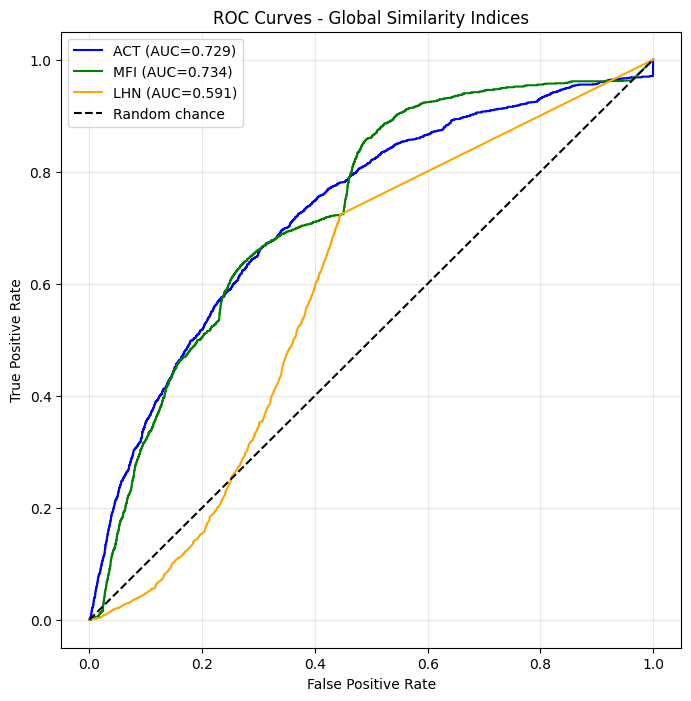

In [42]:
G = intertidal_G.copy()

print("Running link prediction with NACT similarity...")
print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print("=" * 60)

# Run NACT link prediction with K-fold (recommended) 
probs_act, labels_act = getPredictionsKFoldGlobal(G, average_commute_time_index, k=5, n_neg=10)
probs_mfi, labels_mfi = getPredictionsKFoldGlobal(G, matrix_forest_index, k=5, n_neg=10)
probs_lhn, labels_lhn = getPredictionsKFoldGlobal(G, leicht_holme_newman_index, k=5, n_neg=10)



# Compute ROC and AUC
from sklearn.metrics import roc_curve, roc_auc_score
fpr_act, tpr_act, _ = roc_curve(labels_act, probs_act)
auc_act = roc_auc_score(labels_act, probs_act)

fpr_mfi, tpr_mfi, _ = roc_curve(labels_mfi, probs_mfi)
auc_mfi = roc_auc_score(labels_mfi, probs_mfi)

fpr_lhn, tpr_lhn, _ = roc_curve(labels_lhn, probs_lhn)
auc_lhn = roc_auc_score(labels_lhn, probs_lhn)

# Plot together
import matplotlib.pyplot as plt
plt.figure(figsize=(8,8))
plt.plot(fpr_act, tpr_act, "-", label=f"ACT (AUC={auc_act:.3f})", color="blue")
plt.plot(fpr_mfi, tpr_mfi, "-", label=f"MFI (AUC={auc_mfi:.3f})", color="green")
plt.plot(fpr_lhn, tpr_lhn, "-", label=f"LHN (AUC={auc_lhn:.3f})", color="orange")
plt.plot([0,1],[0,1], "--k", label="Random chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Global Similarity Indices")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### running on nearshore

Running link prediction with NACT similarity...
Graph: 513 nodes, 6774 edges
Processing 6774 edges with 5-fold CV...

Fold 1/5


Fold 1 - Test edges: 100%|██████████| 1354/1354 [00:00<?, ?it/s]



Fold 2/5


Fold 2 - Test edges: 100%|██████████| 1354/1354 [00:00<00:00, 298915.08it/s]



Fold 3/5


...

Fold 3 - Test edges: 100%|██████████| 1354/1354 [00:00<?, ?it/s]



Fold 4/5


Fold 4 - Test edges: 100%|██████████| 1354/1354 [00:00<?, ?it/s]



Fold 5/5


Fold 5 - Test edges: 100%|██████████| 1358/1358 [00:00<?, ?it/s]


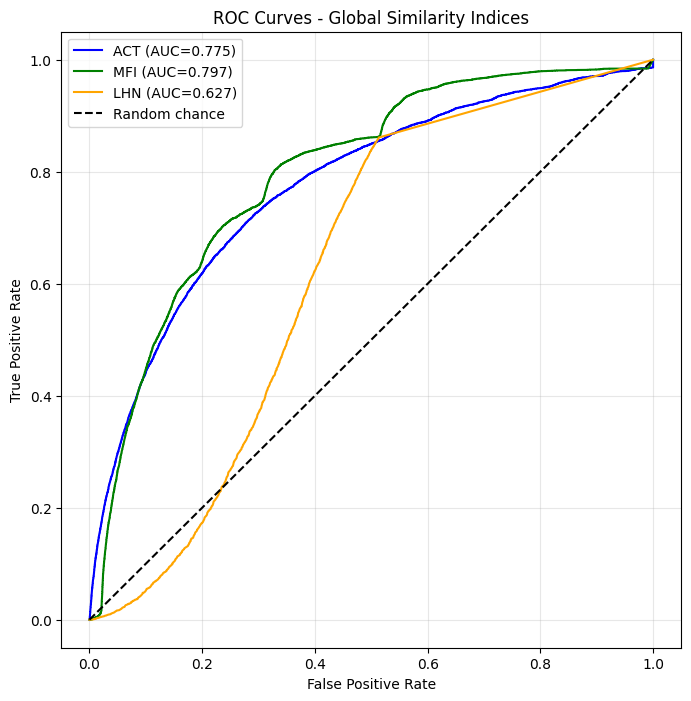

In [44]:
G = nearshore_G.copy()

print("Running link prediction with NACT similarity...")
print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print("=" * 60)

# Run NACT link prediction with K-fold (recommended) 
probs_act, labels_act = getPredictionsKFoldGlobal(G, average_commute_time_index, k=5, n_neg=10)
probs_mfi, labels_mfi = getPredictionsKFoldGlobal(G, matrix_forest_index, k=5, n_neg=10)
probs_lhn, labels_lhn = getPredictionsKFoldGlobal(G, leicht_holme_newman_index, k=5, n_neg=10)



# Compute ROC and AUC
from sklearn.metrics import roc_curve, roc_auc_score
fpr_act, tpr_act, _ = roc_curve(labels_act, probs_act)
auc_act = roc_auc_score(labels_act, probs_act)

fpr_mfi, tpr_mfi, _ = roc_curve(labels_mfi, probs_mfi)
auc_mfi = roc_auc_score(labels_mfi, probs_mfi)

fpr_lhn, tpr_lhn, _ = roc_curve(labels_lhn, probs_lhn)
auc_lhn = roc_auc_score(labels_lhn, probs_lhn)

# Plot together
import matplotlib.pyplot as plt
plt.figure(figsize=(8,8))
plt.plot(fpr_act, tpr_act, "-", label=f"ACT (AUC={auc_act:.3f})", color="blue")
plt.plot(fpr_mfi, tpr_mfi, "-", label=f"MFI (AUC={auc_mfi:.3f})", color="green")
plt.plot(fpr_lhn, tpr_lhn, "-", label=f"LHN (AUC={auc_lhn:.3f})", color="orange")
plt.plot([0,1],[0,1], "--k", label="Random chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Global Similarity Indices")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Do predictions

### top 20 predictions for local similarities

In [ ]:
import pandas as pd
import itertools

def predict_top_missing_links_local(G, similarity_func, taxa_df, top_n=200):
    scores = []

    print("Computing pairwise local similarity scores for non-edges...")
    all_nodes = list(G.nodes())
    non_edges = [(u, v) for u, v in itertools.permutations(all_nodes, 2) if not G.has_edge(u, v)]

    for (u, v) in non_edges:
        score = similarity_func(G, u, v)
        if score > 0:
            scores.append((u, v, score))

    scores.sort(key=lambda x: x[2], reverse=True)
    top_links = scores[:top_n]

    id_to_name = dict(zip(taxa_df["TSN"], taxa_df["Name"]))
    id_to_phylum = dict(zip(taxa_df["TSN"], taxa_df["Phylum"]))

    df_pred = pd.DataFrame([
        {
            "Source_ID": u,
            "Target_ID": v,
            "Source_Name": id_to_name.get(u, "Unknown"),
            "Target_Name": id_to_name.get(v, "Unknown"),
            "Source_Phylum": id_to_phylum.get(u, "Unknown"),
            "Target_Phylum": id_to_phylum.get(v, "Unknown"),
            "Similarity_Score": s
        }
        for (u, v, s) in top_links
    ])

    print(f"Predicted {len(df_pred)} top missing links.")
    
    if not df_pred.empty:
        print("\nTop predicted missing links:\n")
        for _, row in df_pred.iterrows():
            print(f"{row['Source_Name']} ({row['Source_Phylum']}) → {row['Target_Name']} ({row['Target_Phylum']}) | score = {row['Similarity_Score']:.4f}")


    return df_pred


In [71]:
G = G.copy()
print(f"Graph for missing link prediction: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

print("\nPredicting top missing links using directed jaccard coefficient...")
top_missing_act = predict_top_missing_links_local(G, directed_jaccard_coefficient, merged_data, top_n=20)
print("\nPredicting top missing links using directed prederential attachement...")
top_missing_mfi = predict_top_missing_links_local(G, directed_preferential_attachment, merged_data, top_n=20)
print("\nPredicting top missing links using custom similarity...")
top_missing_lhn = predict_top_missing_links_local(G, similarity, merged_data, top_n=20)

Graph for missing link prediction: 520 nodes, 6917 edges

Predicting top missing links using directed jaccard coefficient...
Computing pairwise local similarity scores for non-edges...
Predicted 20 top missing links.

Top predicted missing links:

Bossiella (Rhodophyta) → Chlorophyta Crust (Chlorophyta) | score = 1.0000
Diaulula sandiegensis (Mollusca) → Archidoris montereyensis (Mollusca) | score = 1.0000
Archidoris montereyensis (Mollusca) → Diaulula sandiegensis (Mollusca) | score = 1.0000
Chlorophyta Crust (Chlorophyta) → Bossiella (Rhodophyta) | score = 1.0000
Fratercula corniculata (Chordata) → Fratercula cirrhata (Chordata) | score = 0.7273
Fratercula cirrhata (Chordata) → Fratercula corniculata (Chordata) | score = 0.7273
Neocalanus cristatus (Arthropoda) → Neocalanus plumchrus (Arthropoda) | score = 0.6829
Neocalanus plumchrus (Arthropoda) → Neocalanus cristatus (Arthropoda) | score = 0.6829
Oncorhynchus kisutch (Chordata) → Oncorhynchus tshawytscha (Chordata) | score = 0.6818

### top 20 predictions for global similarities

In [112]:
def predict_top_missing_links(G, similarity_func, taxa_df, top_n=20):
    sim_scores = similarity_func(G)

    id_to_name = dict(zip(taxa_df["TSN"], taxa_df["Name"]))
    id_to_phylum = dict(zip(taxa_df["TSN"], taxa_df["Phylum"]))

    # Filter out existing edges
    missing_links = []
    for (u, v), score in sim_scores.items():
        if not G.has_edge(u, v):
            name_u = id_to_name.get(u, str(u))
            name_v = id_to_name.get(v, str(v))
            phy_u = id_to_phylum.get(u, "Unknown")
            phy_v = id_to_phylum.get(v, "Unknown")
            missing_links.append((u, v, score, name_u, name_v, phy_u, phy_v))

    
    missing_links.sort(key=lambda x: x[2], reverse=True)

    print(f"\nTop {top_n} predicted missing links:")
    print("-" * 90)
    for (u, v, s, name_u, name_v, phy_u, phy_v) in missing_links[:top_n]:
        print(f"{name_u} ({phy_u}) → {name_v} ({phy_v}) | score = {s:.4f}")

    return missing_links[:top_n]


In [113]:
G = G.copy()
print(f"Graph for missing link prediction: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

print("\nPredicting top missing links using Average Commute Time...")
top_missing_act = predict_top_missing_links(G, average_commute_time_index, merged_data, top_n=20)
print("\nPredicting top missing links using Matrix Forest Index...")
top_missing_mfi = predict_top_missing_links(G, matrix_forest_index, merged_data, top_n=20)
print("\nPredicting top missing links using Leicht-Holme-Newman Index...")
top_missing_lhn = predict_top_missing_links(G, leicht_holme_newman_index, merged_data, top_n=20)

Graph for missing link prediction: 520 nodes, 6917 edges

Predicting top missing links using Average Commute Time...

Top 20 predicted missing links:
------------------------------------------------------------------------------------------
Detritus complex (nan) → Gammaridea (Arthropoda) | score = 0.0032
Gammaridea (Arthropoda) → Gadus macrocephalus (Chordata) | score = 0.0031
Detritus complex (nan) → Theragra chalcogramma (Chordata) | score = 0.0030
Detritus complex (nan) → Gadus macrocephalus (Chordata) | score = 0.0029
Gammaridea (Arthropoda) → Cancer (Arthropoda) | score = 0.0027
Gammaridea (Arthropoda) → Homo sapiens (Chordata) | score = 0.0027
Homo sapiens (Chordata) → Gammaridea (Arthropoda) | score = 0.0027
Gammaridea (Arthropoda) → Hippoglossus stenolepis (Chordata) | score = 0.0026
Gammaridea (Arthropoda) → Pandalidae (Arthropoda) | score = 0.0026
Cancer (Arthropoda) → Theragra chalcogramma (Chordata) | score = 0.0026
Detritus complex (nan) → Cancer (Arthropoda) | score = 0.

### Aggregated graph for local similarities

In [110]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import itertools
import numpy as np

def predict_and_visualize_phylum_links(G, similarity_func, taxa_df, 
                                       top_n=300, figsize=(16, 10),
                                       horizontal_spacing=3, vertical_spacing=4,
                                       exclude_unkknown=False, exclude_self_phylum=False,
                                       title="Predicted Phylum-Level Interactions"):

    print(f"Computing pairwise local similarity scores for non-edges ({similarity_func.__name__})...")
    all_nodes = list(G.nodes())
    non_edges = [(u, v) for u, v in itertools.permutations(all_nodes, 2) if not G.has_edge(u, v)]

    scores = []
    for (u, v) in non_edges:
        score = similarity_func(G, u, v)
        if score > 0:
            scores.append((u, v, score))

    scores.sort(key=lambda x: x[2], reverse=True)
    top_links = scores[:top_n]

    id_to_name = dict(zip(taxa_df["TSN"], taxa_df["Name"]))
    id_to_phylum = dict(zip(taxa_df["TSN"], taxa_df["Phylum"]))

    df_pred = pd.DataFrame([
        {
            "Source_ID": u,
            "Target_ID": v,
            "Source_Name": id_to_name.get(u, "Unknown"),
            "Target_Name": id_to_name.get(v, "Unknown"),
            "Source_Phylum": id_to_phylum.get(u, "Unknown"),
            "Target_Phylum": id_to_phylum.get(v, "Unknown"),
            "Similarity_Score": s
        }
        for (u, v, s) in top_links
    ])
    
    # Optionally exclude links involving "Unknown" phylum
    if exclude_unkknown:
        df_pred = df_pred[
            (df_pred["Source_Phylum"] != "Unknown") & 
            (df_pred["Target_Phylum"] != "Unknown")
        ]

    print(f"Predicted {len(df_pred)} top missing links.")
    print("\nExample predicted links:")
    for _, row in df_pred.head(10).iterrows():
        print(f"{row['Source_Name']} ({row['Source_Phylum']}) → {row['Target_Name']} ({row['Target_Phylum']}) | score = {row['Similarity_Score']:.4f}")

    # Aggregate predictions by Phylum
    phylum_connections = (
        df_pred.groupby(["Source_Phylum", "Target_Phylum"])
               .size()
               .reset_index(name="count")
    )
    print(f"\nAggregated {len(phylum_connections)} Phylum-level connections.")

  
    phylum_graph = nx.DiGraph()

   
    all_phyla = set(df_pred["Source_Phylum"]).union(set(df_pred["Target_Phylum"]))
    for phylum in all_phyla:
        phylum_graph.add_node(phylum, name=phylum)

    
    for _, row in phylum_connections.iterrows():
        # Only skip if the phyla are the same AND the exclusion flag is True
        if exclude_self_phylum and row["Source_Phylum"] == row["Target_Phylum"]:
            continue
            
        phylum_graph.add_edge(row["Source_Phylum"], row["Target_Phylum"], weight=row["count"])

    print(f"Phylum-level graph has {phylum_graph.number_of_nodes()} nodes and {phylum_graph.number_of_edges()} edges")


    plt.figure(figsize=(15, 10))
    levels = {}

    # Compute hierarchical levels robustly using Condensation/Topological Sort
    try:
        C = nx.condensation(phylum_graph)
        comp_map = C.graph.get('mapping', {})
        topo = list(nx.topological_sort(C))
        comp_order = {comp_id: idx for idx, comp_id in enumerate(topo)}
        levels = {node: comp_order[comp_map[node]] for node in phylum_graph.nodes()}
    except Exception:
        print("Warning: Condensation/topo failed; falling back to in-degree levels.")
        levels = {n: phylum_graph.in_degree(n) for n in phylum_graph.nodes()}

    unique_levels = sorted(set(levels.values()))
    level_map = {val:i for i,val in enumerate(unique_levels)}
    levels = {n: level_map[levels[n]] for n in levels}

    level_counts = {}
    pos = {}
    sorted_nodes = sorted(phylum_graph.nodes(), key=lambda x: (levels[x], x))
    for node in sorted_nodes:
        lvl = levels[node]
        idx = level_counts.get(lvl, 0)
        x = idx * horizontal_spacing
        y = -lvl * vertical_spacing
        pos[node] = (x, y)
        level_counts[lvl] = idx + 1

    max_level = max(levels.values()) if levels.values() else 1
    node_colors = [plt.cm.viridis(levels.get(node, 0) / (max_level + 1e-9)) for node in phylum_graph.nodes()]
    
    nx.draw_networkx_nodes(phylum_graph, pos, 
                            node_color=node_colors,
                            cmap=plt.cm.viridis,
                            node_size=1500,
                            alpha=0.85,
                            edgecolors='black',
                            linewidths=2)

    edges = phylum_graph.edges()
    weights = [phylum_graph[u][v]['weight'] for u, v in edges]
    if weights:
        max_w, min_w = max(weights), min(weights)
        normalized_w = [(w - min_w) / (max_w - min_w + 1e-6) * 8 + 1 for w in weights]
    else:
        normalized_w = [3]

    edge_colors = []
    for u, v in edges:
        if levels.get(u, 0) < levels.get(v, 0):
            edge_colors.append('red') # Upward flow (low index/level → high index/level)
        elif levels.get(u, 0) > levels.get(v, 0):
            edge_colors.append('blue') # Downward flow
        else:
            edge_colors.append('gray') # Same level

    nx.draw_networkx_edges(phylum_graph, pos,
                            width=normalized_w,
                            alpha=0.7,
                            edge_color=edge_colors,
                            arrows=True,
                            arrowsize=25)

    labels = {node: phylum_graph.nodes[node]['name'] for node in phylum_graph.nodes()}
    label_pos = {n: (pos[n][0], pos[n][1] - 0.25) for n in phylum_graph.nodes()}
    nx.draw_networkx_labels(phylum_graph, label_pos, labels=labels, font_size=10, font_weight='bold',
                            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

    sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=max_level))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=plt.gca(), shrink=0.8)
    cbar.set_label('Trophic Level (normalized index)', rotation=270, labelpad=20)

    legend_elements = [
        Patch(facecolor='red', label='Upward flow (low → high level)'),
        Patch(facecolor='blue', label='Downward flow (high → low level)'),
        Patch(facecolor='gray', label='Same level')
    ]
    plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.15, 1))

    plt.title(title, fontsize=14, pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print("\nTop 10 phylum connections (by count):")
    for i, row in phylum_connections.sort_values('count', ascending=False).head(10).iterrows():
        print(f"{i+1}. {row['Source_Phylum']} → {row['Target_Phylum']}: {row['count']} predicted links")

    return df_pred, phylum_graph

Computing pairwise local similarity scores for non-edges (directed_jaccard_coefficient)...
Predicted 400 top missing links.

Example predicted links:
Bossiella (Rhodophyta) → Chlorophyta Crust (Chlorophyta) | score = 1.0000
Diaulula sandiegensis (Mollusca) → Archidoris montereyensis (Mollusca) | score = 1.0000
Archidoris montereyensis (Mollusca) → Diaulula sandiegensis (Mollusca) | score = 1.0000
Chlorophyta Crust (Chlorophyta) → Bossiella (Rhodophyta) | score = 1.0000
Fratercula corniculata (Chordata) → Fratercula cirrhata (Chordata) | score = 0.7273
Fratercula cirrhata (Chordata) → Fratercula corniculata (Chordata) | score = 0.7273
Neocalanus cristatus (Arthropoda) → Neocalanus plumchrus (Arthropoda) | score = 0.6829
Neocalanus plumchrus (Arthropoda) → Neocalanus cristatus (Arthropoda) | score = 0.6829
Oncorhynchus kisutch (Chordata) → Oncorhynchus tshawytscha (Chordata) | score = 0.6818
Oncorhynchus tshawytscha (Chordata) → Oncorhynchus kisutch (Chordata) | score = 0.6818

Aggregate

c:\Users\anant\anaconda3\envs\network_statistics\lib\site-packages\networkx\drawing\nx_pylab.py:457: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


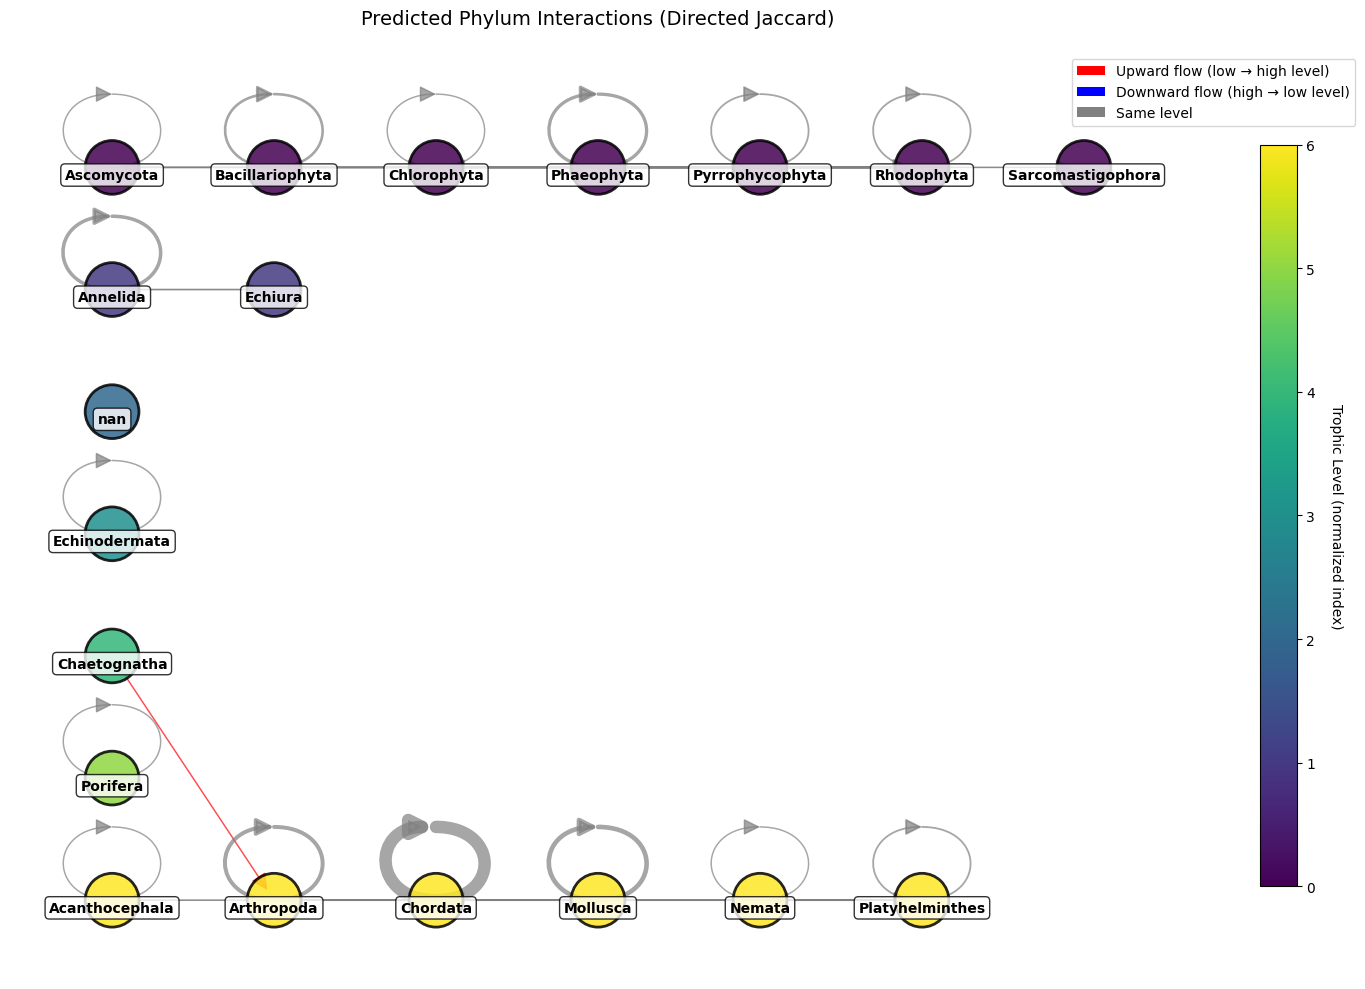


Top 10 phylum connections (by count):
21. Chordata → Chordata: 135 predicted links
27. Mollusca → Mollusca: 40 predicted links
5. Arthropoda → Arthropoda: 32 predicted links
3. Annelida → Annelida: 27 predicted links
31. Phaeophyta → Phaeophyta: 24 predicted links
12. Bacillariophyta → Bacillariophyta: 16 predicted links
32. Phaeophyta → Rhodophyta: 12 predicted links
45. Rhodophyta → Phaeophyta: 12 predicted links
44. Rhodophyta → Chlorophyta: 7 predicted links
19. Chlorophyta → Rhodophyta: 7 predicted links
Computing pairwise local similarity scores for non-edges (directed_preferential_attachment)...
Predicted 400 top missing links.

Example predicted links:
Homo sapiens (Chordata) → Gammaridea (Arthropoda) | score = 19926.0000
Eumetopias jubatus (Chordata) → Detritus complex (nan) | score = 14784.0000
Eumetopias jubatus (Chordata) → Gammaridea (Arthropoda) | score = 13608.0000
Phoca vitulina (Chordata) → Detritus complex (nan) | score = 11968.0000
Homo sapiens (Chordata) → Hyperiid

c:\Users\anant\anaconda3\envs\network_statistics\lib\site-packages\networkx\drawing\nx_pylab.py:457: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


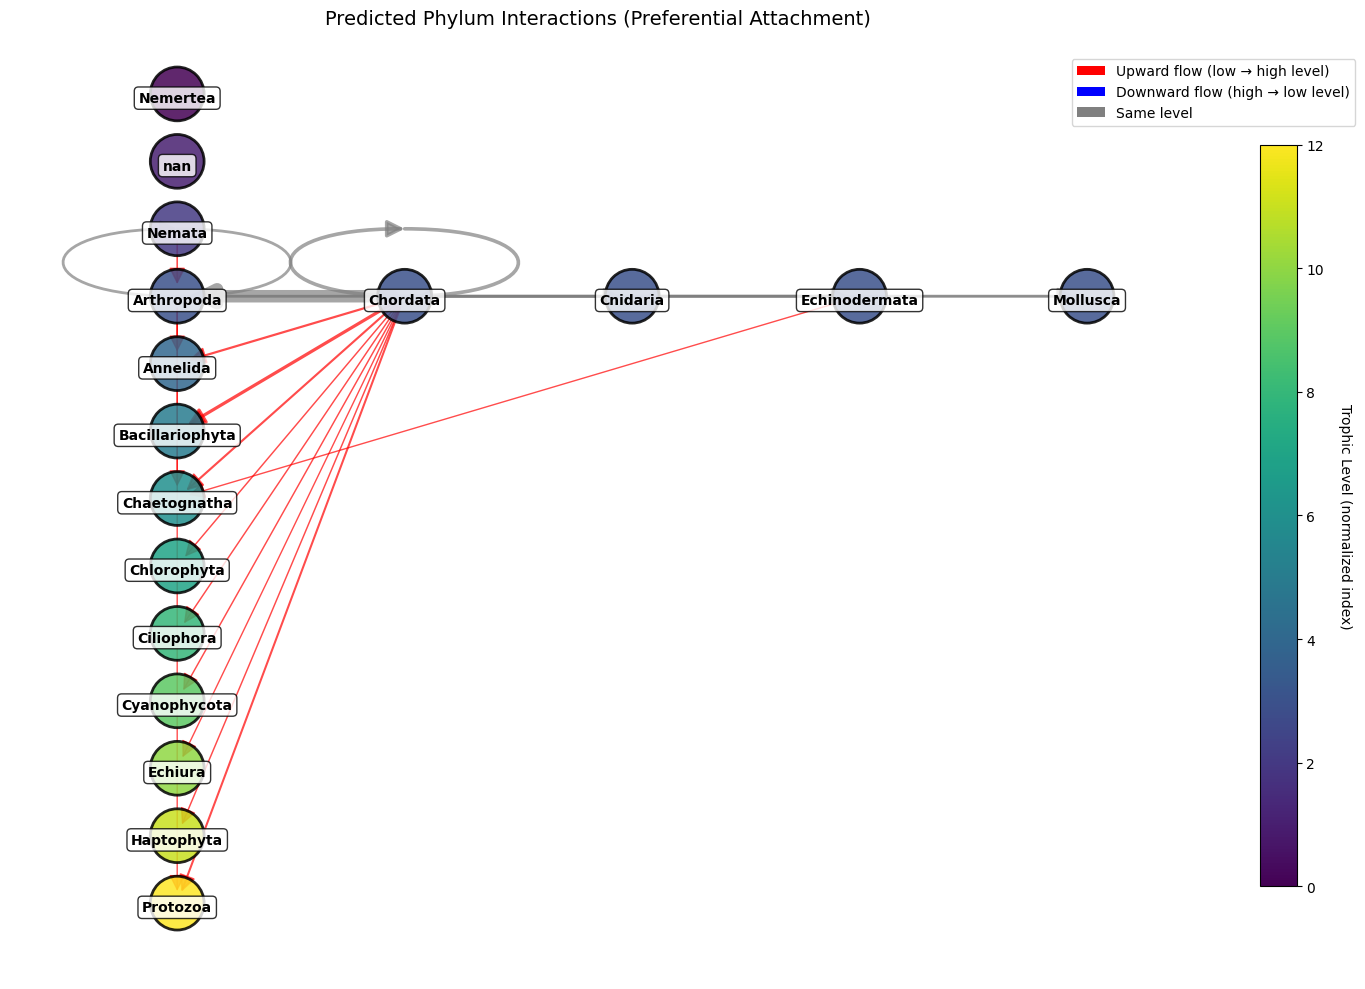


Top 10 phylum connections (by count):
8. Chordata → Arthropoda: 135 predicted links
12. Chordata → Chordata: 28 predicted links
9. Chordata → Bacillariophyta: 23 predicted links
19. Chordata → Mollusca: 20 predicted links
22. Echinodermata → Arthropoda: 19 predicted links
2. Arthropoda → Arthropoda: 18 predicted links
7. Chordata → Annelida: 11 predicted links
14. Chordata → Cnidaria: 11 predicted links
10. Chordata → Chaetognatha: 10 predicted links
26. Mollusca → Arthropoda: 9 predicted links
Computing pairwise local similarity scores for non-edges (similarity)...
Predicted 400 top missing links.

Example predicted links:
Calanus (Arthropoda) → Thalassiothrix (Bacillariophyta) | score = 0.6757
Oncorhynchus kisutch (Chordata) → Sebastes crameri (Chordata) | score = 0.6556
Oncorhynchus kisutch (Chordata) → Sebastes entomelas (Chordata) | score = 0.6556
Oncorhynchus kisutch (Chordata) → Sebastes wilsoni (Chordata) | score = 0.6556
Oncorhynchus kisutch (Chordata) → Sebastes zacentrus (C

c:\Users\anant\anaconda3\envs\network_statistics\lib\site-packages\networkx\drawing\nx_pylab.py:457: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


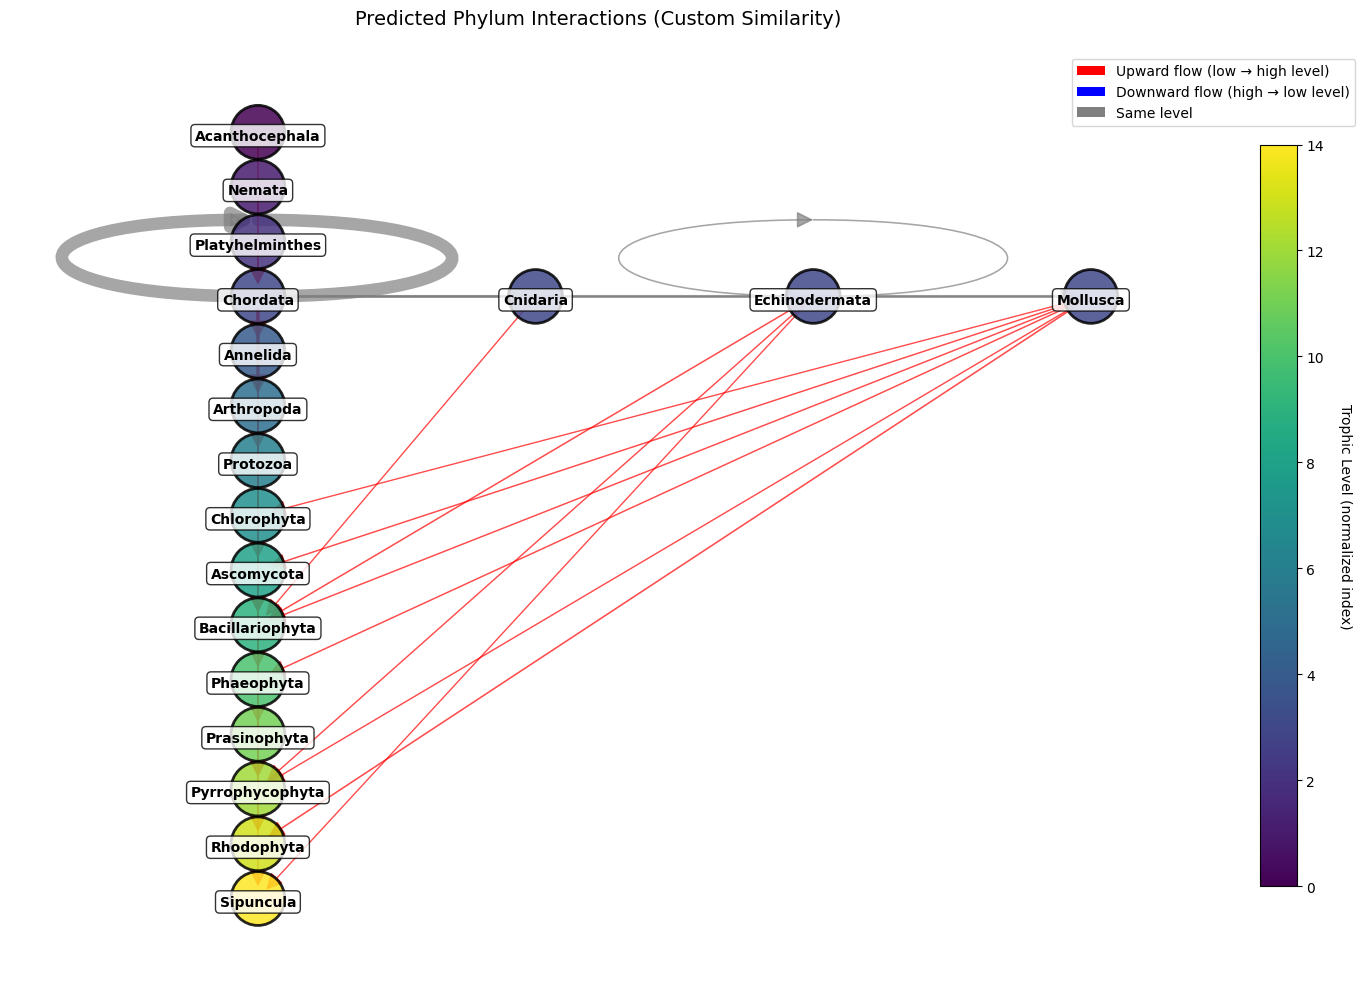


Top 10 phylum connections (by count):
12. Chordata → Chordata: 215 predicted links
10. Chordata → Arthropoda: 44 predicted links
9. Chordata → Annelida: 32 predicted links
15. Chordata → Mollusca: 32 predicted links
3. Arthropoda → Bacillariophyta: 7 predicted links
4. Arthropoda → Phaeophyta: 6 predicted links
31. Mollusca → Rhodophyta: 5 predicted links
14. Chordata → Echinodermata: 5 predicted links
7. Arthropoda → Rhodophyta: 5 predicted links
21. Echinodermata → Echinodermata: 5 predicted links


In [111]:
G = G.copy()

df_pred_jaccard, phylum_graph_jaccard = predict_and_visualize_phylum_links(
    G, directed_jaccard_coefficient, merged_data, top_n=400,
    title="Predicted Phylum Interactions (Directed Jaccard)"
)

df_pred_pa, phylum_graph_pa = predict_and_visualize_phylum_links(
    G, directed_preferential_attachment, merged_data, top_n=400,
    title="Predicted Phylum Interactions (Preferential Attachment)"
)

df_pred_custom, phylum_graph_custom = predict_and_visualize_phylum_links(
    G, similarity, merged_data, top_n=400,
    title="Predicted Phylum Interactions (Custom Similarity)"
)


### Aggregated graph for global similarities

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_predicted_phylum_hierarchy(G, similarity_func, taxa_df,
                                    top_n=300, figsize=(16,10),
                                    horizontal_spacing=3, vertical_spacing=4,
                                    exclude_unknown=False, exclude_self_phylum=False,
                                    cmap=plt.cm.viridis):

    print(f"Computing similarity scores with {similarity_func.__name__} ... (this may be slow)")
    sim_scores = similarity_func(G) 
    
    predicted = [(u, v, s) for (u, v), s in sim_scores.items() if (u != v) and (not G.has_edge(u, v))]
    if not predicted:
        raise ValueError("No predicted missing links found (sim_scores empty or all pairs are edges).")
    predicted.sort(key=lambda x: x[2], reverse=True)
    top_predicted = predicted[:top_n]
    print(f"Selected top {len(top_predicted)} predicted species-level links for aggregation.")
    
    id_to_phylum = dict(zip(taxa_df["TSN"], taxa_df["Phylum"]))

    def get_phylum(node):
        p = id_to_phylum.get(node, None)
        if p is None:
            p = id_to_phylum.get(str(node), None)
        return p if p is not None else "Unknown"
    
    #  aggregate into phylum->phylum counts
    phylum_counts = {}  
    phylum_score_sum = {}
    for u, v, score in top_predicted:
        pu = get_phylum(u)
        pv = get_phylum(v)
        if exclude_unknown and (pu == "Unknown" or pv == "Unknown"):
            continue
        if exclude_self_phylum and (pu == pv):
            continue
        key = (pu, pv)
        phylum_counts[key] = phylum_counts.get(key, 0) + 1
        phylum_score_sum[key] = phylum_score_sum.get(key, 0.0) + score
    
    if not phylum_counts:
        raise ValueError("No phylum-level edges after aggregation (check taxa_df mapping and exclude flags).")
    
    #  build phylum-level directed graph 
    P = nx.DiGraph()
    phyla = set([k[0] for k in phylum_counts.keys()] + [k[1] for k in phylum_counts.keys()])
    for p in phyla:
        P.add_node(p)
    for (pu, pv), cnt in phylum_counts.items():
        avg_score = phylum_score_sum[(pu,pv)] / cnt
        P.add_edge(pu, pv, weight=cnt, avg_score=avg_score)
    print(f"Aggregated to {P.number_of_nodes()} phyla and {P.number_of_edges()} phylum-level edges.")
    
    #  compute hierarchical levels robustly
    try:
        C = nx.condensation(P)  #
        comp_map = C.graph.get('mapping', {})  
        topo = list(nx.topological_sort(C))    
        comp_order = {comp_id: idx for idx, comp_id in enumerate(topo)}
        # assign level for each original phylum as the topo index of its component
        levels = {node: comp_order[comp_map[node]] for node in P.nodes()}
    except Exception:
        print("Warning: condensation/topo failed; falling back to weighted in-degree for levels.")
        levels = {n: P.in_degree(n, weight='weight') for n in P.nodes()}
        unique = sorted(set(levels.values()))
        level_map = {val:i for i,val in enumerate(unique)}
        levels = {n: level_map[levels[n]] for n in levels}
    

    unique_levels = sorted(set(levels.values()))
    level_map = {val:i for i,val in enumerate(unique_levels)}
    levels = {n: level_map[levels[n]] for n in levels}
    

    level_counts = {}
    pos = {}
    for node in sorted(P.nodes(), key=lambda x: (levels[x], x)):
        lvl = levels[node]
        idx = level_counts.get(lvl, 0)
        x = idx * horizontal_spacing
        y = -lvl * vertical_spacing   
        pos[node] = (x, y)
        level_counts[lvl] = idx + 1
    
    

    plt.figure(figsize=figsize)
    

    level_vals = np.array([levels[n] for n in P.nodes()])
    max_level = level_vals.max() if len(level_vals) else 1
    node_colors = [cmap(levels[n] / (max_level + 1e-9)) for n in P.nodes()]
    

    node_sizes = []
    for n in P.nodes():
        degw = P.in_degree(n, weight='weight') + P.out_degree(n, weight='weight')
        node_sizes.append(600 + 100 * degw)
    
    nx.draw_networkx_nodes(P, pos,
                           node_color=node_colors,
                           node_size=node_sizes,
                           edgecolors='black',
                           linewidths=1.2)
   
    weights = [d['weight'] for _,_,d in P.edges(data=True)]
    if weights:
        wmin, wmax = min(weights), max(weights)
        if wmax > wmin:
            widths = [1 + ( (w - wmin) / (wmax - wmin) ) * 7 for w in weights]  
        else:
            widths = [3 for _ in weights]
    else:
        widths = [2 for _ in P.edges()]
    
    
    edge_colors = []
    for u, v in P.edges():
        if levels[u] < levels[v]:
            edge_colors.append('red')    
        elif levels[u] > levels[v]:
            edge_colors.append('blue')   
        else:
            edge_colors.append('gray')   
    
    nx.draw_networkx_edges(P, pos,
                           width=widths,
                           edge_color=edge_colors,
                           alpha=0.8,
                           arrows=True,
                           arrowsize=20,
                           arrowstyle='->')
    
    label_pos = {n: (pos[n][0], pos[n][1] - 0.25) for n in P.nodes()}
    nx.draw_networkx_labels(P, label_pos, font_size=10, font_weight='bold',
                            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.9))
    
    legend_elements = [
        Patch(facecolor='red', label='Upward flow (lower → higher level)'),
        Patch(facecolor='blue', label='Downward flow (higher → lower level)'),
        Patch(facecolor='gray', label='Same level')
    ]
    plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.25, 1))
    
    plt.title(f"Hierarchical Phylum-Level Predictions ({similarity_func.__name__}, top {len(top_predicted)})",
              fontsize=14, pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    sorted_phylum_edges = sorted(phylum_counts.items(), key=lambda x: x[1], reverse=True)
    print("\nTop 10 predicted phylum->phylum connections (by count):")
    for i, ((pu, pv), cnt) in enumerate(sorted_phylum_edges[:10]):
        avg_score = phylum_score_sum[(pu,pv)] / cnt
        print(f"{i+1}. {pu} -> {pv}: {cnt} predicted species-links (avg score={avg_score:.4f})")
    
    out_strength = {n: P.out_degree(n, weight='weight') for n in P.nodes()}
    root = max(out_strength, key=out_strength.get) if out_strength else None
    
    return P, pos, root, top_predicted

Computing similarity scores with matrix_forest_index ... (this may be slow)
Selected top 400 predicted species-level links for aggregation.
Aggregated to 27 phyla and 72 phylum-level edges.


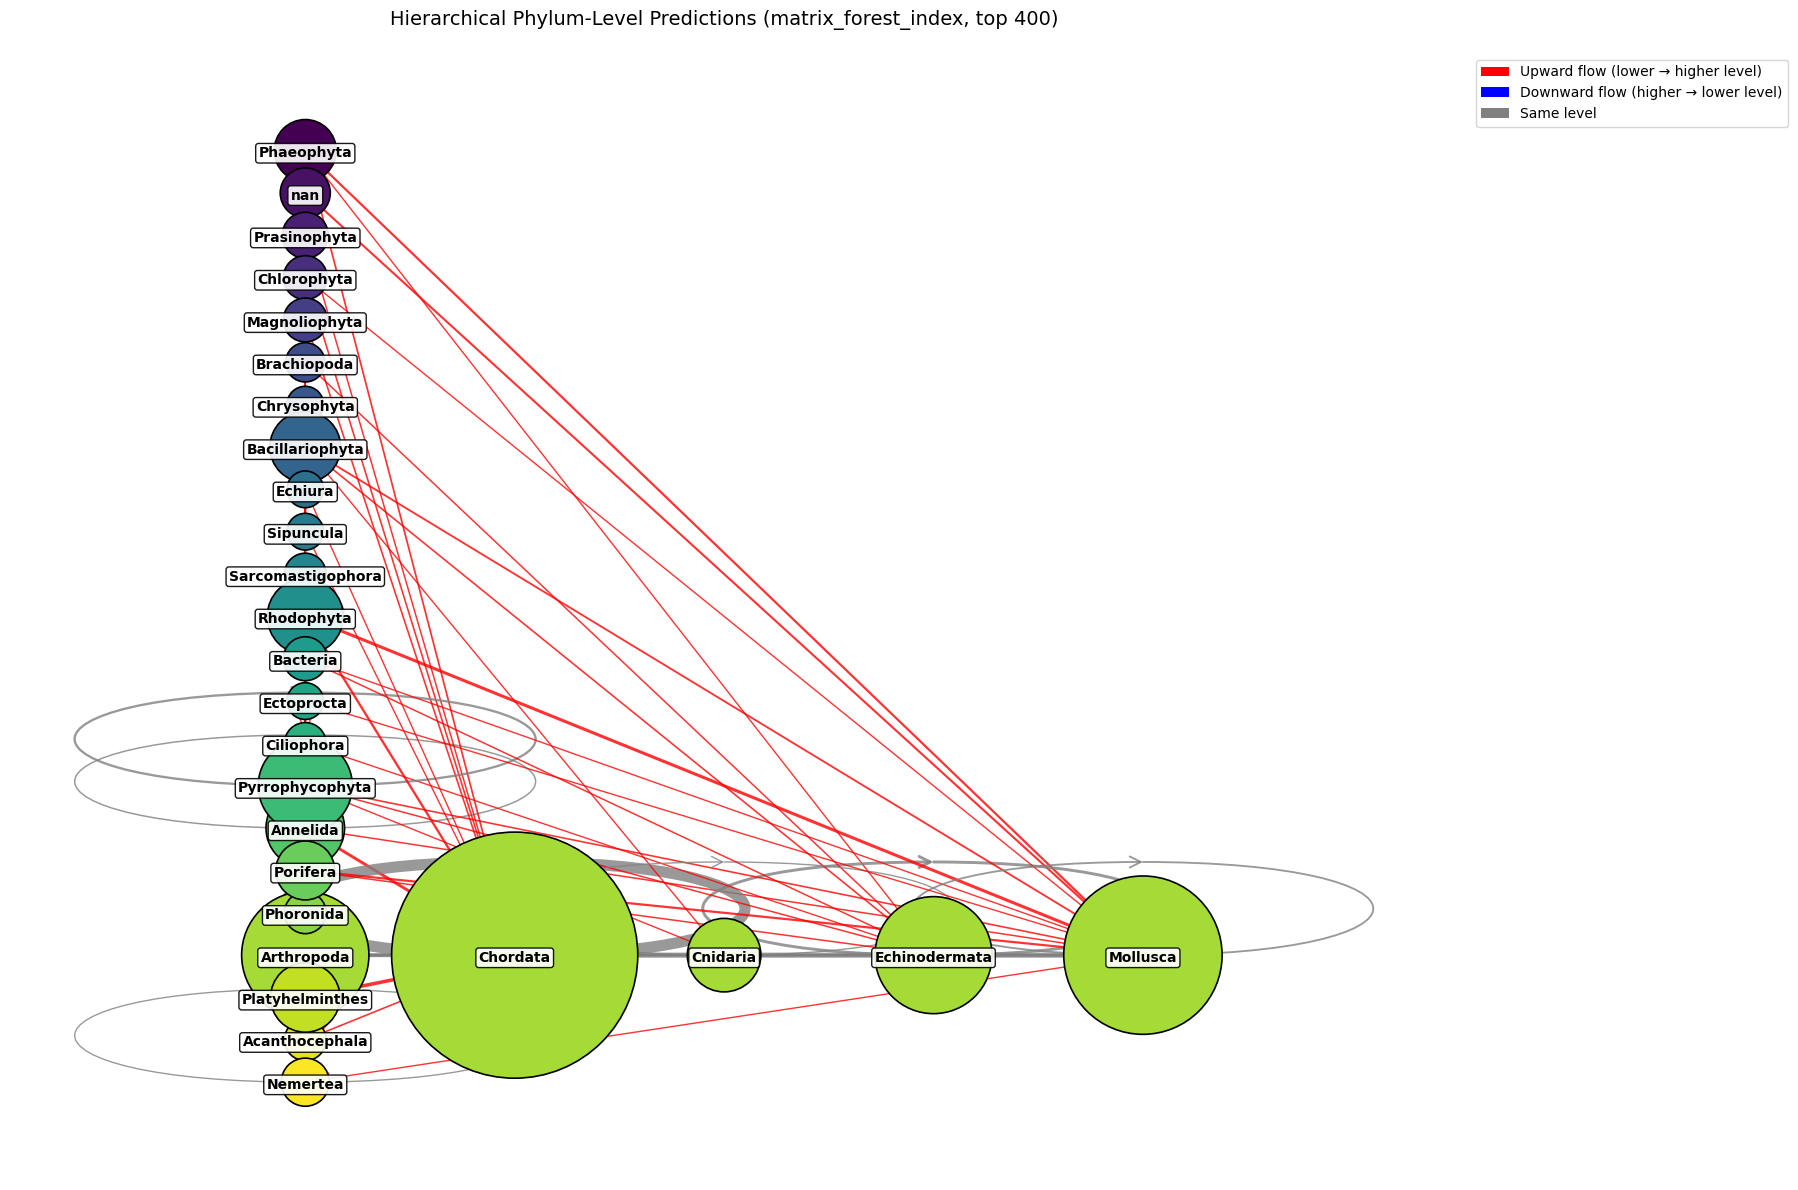


Top 10 predicted phylum->phylum connections (by count):
1. Chordata -> Chordata: 83 predicted species-links (avg score=0.0044)
2. Mollusca -> Chordata: 32 predicted species-links (avg score=0.0044)
3. Arthropoda -> Chordata: 23 predicted species-links (avg score=0.0044)
4. Chordata -> Platyhelminthes: 19 predicted species-links (avg score=0.0044)
5. Rhodophyta -> Mollusca: 15 predicted species-links (avg score=0.0044)
6. Echinodermata -> Echinodermata: 14 predicted species-links (avg score=0.0044)
7. Annelida -> Chordata: 14 predicted species-links (avg score=0.0043)
8. Chordata -> Arthropoda: 11 predicted species-links (avg score=0.0044)
9. Pyrrophycophyta -> Arthropoda: 10 predicted species-links (avg score=0.0043)
10. Rhodophyta -> Chordata: 9 predicted species-links (avg score=0.0045)


In [109]:
P, pos, root, top_pred = plot_predicted_phylum_hierarchy(
    G,
    matrix_forest_index,
    merged_data,
    top_n=400,
    figsize=(18,12)
)